# Atlantic Haven Hotels — Prédiction d'annulation de réservation
### Hackathon ML & Data Science — ISPM — M1 — Semestre 2 — Examen final

**Cible :** `reservation_annulee` (0 = maintenue, 1 = annulée)
**Métrique :** F1-score sur la classe « annulation »

Ce notebook est la **fusion automatique** des notebooks d'étape se trouvant dans `notebooks/`
(chacun exécutable indépendamment). Le code réutilisable est factorisé dans le package `src/`.

Sommaire :
1. `01_eda.ipynb` — EDA et préparation
2. `02_baseline.ipynb` — Baseline (régression logistique)
3. `03_modelisation.ipynb` — Validation temporelle et modélisation
4. `04_feature_engineering.ipynb` — Feature engineering
5. `05_interpretation.ipynb` — Interprétation et analyse d'erreurs
6. `06_submission.ipynb` — Génération de `submission.csv`

---


# 01 — EDA et préparation
### Atlantic Haven Hotels — Prédiction d'annulation de réservation

Ce notebook correspond à l'**étape 1** du sujet : analyse de la cible, des valeurs manquantes,
des distributions, des catégories, des valeurs atypiques et des relations temporelles.

Le code réutilisable (chargement des données, configuration) est factorisé dans le package
`src/`, importé ci-dessous.

## 0. Configuration et chargement des données

In [1]:
import sys, os
# Résolution robuste du chemin racine du projet, que ce notebook soit exécuté
# seul depuis notebooks/ ou fusionné à la racine dans notebook.ipynb
for _candidate in (".", ".."):
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from src.config import RANDOM_STATE
from src.data import load_train_test

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

print("Setup OK — graine aléatoire fixée à", RANDOM_STATE)

Setup OK — graine aléatoire fixée à 42


In [2]:
train, test, data_dict = load_train_test()

print("Train :", train.shape)
print("Test  :", test.shape)
train.head()

Train : (8000, 34)
Test  : (2000, 33)


,reservation_id,date_reservation,date_arrivee,region_hotel,ville,type_destination,hotel_id,categorie_hotel,segment_client,marche_origine,canal_reservation,moyen_transport,delai_reservation_jours,nuits,adultes,enfants,chambres,formule_repas,tarif_remboursable,type_acompte,prix_moyen_nuit_eur,remise_pct,montant_total_eur,client_type,reservations_passees,annulations_passees,demandes_speciales,modifications_reservation,jours_liste_attente,evenement_majeur,haute_saison_regionale,arrivee_weekend,agent_id,reservation_annulee
0,R000808,2023-01-01,2023-03-13,Campania,Napoli,urbaine_cotiere,CAM-4-2,4,loisirs_couple,Europe_Ouest,plateforme_en_ligne,avion_direct,71,4,2,0.0,1,aucune,non,total,165.72,3,642.99,nouveau,0,0,1.0,0,0,0,0,0,AG036,0
1,R001808,2023-01-01,2023-01-07,Lazio,Roma,urbaine_culturelle,LAZ-4-3,4,affaires,Ameriques,plateforme_en_ligne,train,6,3,2,1.0,1,petit_dejeuner,oui,partiel,187.00,0,561.00,fidele,9,1,2.0,1,0,0,0,1,AG005,1
2,R002130,2023-01-01,2023-03-26,Lombardia,Milano,affaires_lacs,LOM-4-2,4,loisirs_couple,Autres,agence,avion_direct,84,3,2,0.0,1,aucune,oui,aucun,180.61,1,536.41,nouveau,0,0,2.0,2,0,0,0,0,AG043,1
3,R003635,2023-01-01,2023-01-09,Liguria,Genova,littorale,LIG-4-1,4,famille,Ameriques,plateforme_en_ligne,voiture,8,3,2,1.0,1,petit_dejeuner,oui,aucun,202.10,7,563.86,nouveau,0,0,0.0,0,0,1,0,0,AG031,0
4,R004683,2023-01-01,2023-01-11,Sardegna,Cagliari,insulaire_balneaire,SAR-3-2,3,loisirs_couple,Italie,site_hotel,ferry,10,4,2,0.0,1,petit_dejeuner,non,total,138.89,4,533.34,nouveau,0,0,2.0,1,0,0,0,0,NaN,0


In [3]:
data_dict

,variable,type,description,fichier_test
0,reservation_id,identifiant,Identifiant unique de la réservation,oui
1,date_reservation,date,Date de création de la réservation,oui
2,date_arrivee,date,Date d’arrivée prévue,oui
3,region_hotel,catégorielle,Région administrative italienne de l’hôtel,oui
4,ville,catégorielle,Ville principale associée à l’établissement,oui
5,type_destination,catégorielle,Profil touristique dominant de la destination,oui
6,hotel_id,catégorielle,Identifiant synthétique de l’hôtel,oui
7,categorie_hotel,entier,"Catégorie de l’hôtel, en étoiles",oui
8,segment_client,catégorielle,Motif ou composition principale du séjour,oui
9,marche_origine,catégorielle,"Grande zone de marché, non assimilable à une n...",oui


### 1.1 Vue d'ensemble et typage

In [4]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   reservation_id             8000 non-null   str           
 1   date_reservation           8000 non-null   datetime64[us]
 2   date_arrivee               8000 non-null   datetime64[us]
 3   region_hotel               8000 non-null   str           
 4   ville                      8000 non-null   str           
 5   type_destination           8000 non-null   str           
 6   hotel_id                   8000 non-null   str           
 7   categorie_hotel            8000 non-null   int64         
 8   segment_client             8000 non-null   str           
 9   marche_origine             7809 non-null   str           
 10  canal_reservation          8000 non-null   str           
 11  moyen_transport            8000 non-null   str           
 12  delai_reservation

### 1.2 Distribution de la cible

La cible est déséquilibrée : environ un quart des réservations sont annulées. C'est ce déséquilibre,
combiné à l'asymétrie du coût des erreurs (voir README), qui justifie l'usage du **F1-score** plutôt
que l'accuracy comme métrique d'évaluation (une accuracy élevée peut être obtenue en prédisant
toujours « pas d'annulation »).

reservation_annulee
0    0.741625
1    0.258375
Name: proportion, dtype: float64


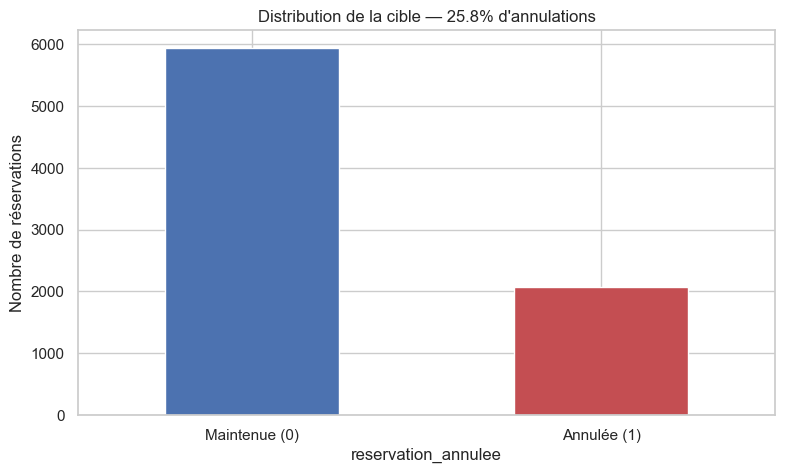

In [5]:
target_rate = train["reservation_annulee"].value_counts(normalize=True)
print(target_rate)

fig, ax = plt.subplots()
train["reservation_annulee"].value_counts().sort_index().plot(kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_xticklabels(["Maintenue (0)", "Annulée (1)"], rotation=0)
ax.set_title(f"Distribution de la cible — {target_rate[1]*100:.1f}% d'annulations")
ax.set_ylabel("Nombre de réservations")
plt.show()

### 1.3 Valeurs manquantes

On inspecte les valeurs manquantes dans le train et le test. Un point important : `agent_id` n'est pas
une variable "manquante" au sens statistique — elle est **structurellement vide** pour les canaux de
réservation directs (site hôtel, téléphone, entreprise) et toujours renseignée pour les canaux
intermédiés (agence, plateforme en ligne). Ce n'est donc pas un problème à imputer, mais une information
déjà capturée par `canal_reservation`.

In [6]:
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_pct = (missing_train / len(train) * 100).round(2)
pd.DataFrame({"n_manquant": missing_train, "%_manquant": missing_pct})

,n_manquant,%_manquant
agent_id,3354,41.92
enfants,355,4.44
prix_moyen_nuit_eur,193,2.41
marche_origine,191,2.39
demandes_speciales,157,1.96


In [7]:
# Vérification : agent_id manquant <=> canal de réservation direct
pd.crosstab(train["canal_reservation"], train["agent_id"].isna(), rownames=["canal_reservation"], colnames=["agent_id manquant"])

agent_id manquant,False,True
canal_reservation,,
agence,1325,0
entreprise,0,622
plateforme_en_ligne,3321,0
site_hotel,0,2013
telephone,0,719


In [8]:
# Les autres valeurs manquantes (marche_origine, enfants, prix_moyen_nuit_eur, demandes_speciales)
# sont-elles liées à la cible ? Si le taux d'annulation est similaire manquant/présent, on peut
# considérer une imputation simple sans risque de biais fort.
for c in ["marche_origine", "enfants", "prix_moyen_nuit_eur", "demandes_speciales"]:
    m = train[c].isna()
    print(f"{c:25s} | taux annulation (manquant)={train.loc[m,'reservation_annulee'].mean():.3f} "
          f"| (présent)={train.loc[~m,'reservation_annulee'].mean():.3f} | n_manquant={m.sum()}")

marche_origine            | taux annulation (manquant)=0.209 | (présent)=0.260 | n_manquant=191
enfants                   | taux annulation (manquant)=0.282 | (présent)=0.257 | n_manquant=355
prix_moyen_nuit_eur       | taux annulation (manquant)=0.181 | (présent)=0.260 | n_manquant=193
demandes_speciales        | taux annulation (manquant)=0.280 | (présent)=0.258 | n_manquant=157


**Décision de traitement des valeurs manquantes** (appliquée uniquement avec des statistiques
apprises sur le train, dans le pipeline scikit-learn de `src/preprocessing.py`, pour éviter toute
fuite) :

- `enfants`, `demandes_speciales` : imputation par la **médiane** (variables de comptage, distribution
  asymétrique) ;
- `prix_moyen_nuit_eur` : imputation par la **médiane** ;
- `marche_origine` : imputation par une catégorie explicite `"Inconnu"` plutôt que le mode, pour ne pas
  fabriquer un signal artificiel ;
- `agent_id` : conservé comme catégorie (`NaN` → `"direct"`), redondant avec `canal_reservation` mais
  utile si l'on veut capter un effet agent.

### 1.4 Cardinalité des variables catégorielles

In [9]:
cat_cols = ["region_hotel", "ville", "type_destination", "hotel_id", "categorie_hotel",
            "segment_client", "marche_origine", "canal_reservation", "moyen_transport",
            "formule_repas", "tarif_remboursable", "type_acompte", "client_type", "agent_id"]

card = pd.Series({c: train[c].nunique() for c in cat_cols}).sort_values(ascending=False)
card

hotel_id              84
agent_id              45
region_hotel          10
ville                 10
type_destination      10
marche_origine         6
segment_client         5
canal_reservation      5
moyen_transport        5
formule_repas          4
categorie_hotel        3
type_acompte           3
client_type            3
tarif_remboursable     2
dtype: int64

On remarque que `region_hotel`, `ville` et `type_destination` sont en **relation biunivoque** (1 région
= 1 ville = 1 type de destination) : ce sont trois vues de la même dimension géographique. On ne
conservera que `type_destination` (plus riche en information touristique) et `hotel_id` sera également
écarté (84 modalités, redondant, risque de sur-apprentissage) — décision appliquée dans
`src/config.DROP_COLS`, réutilisée dès le notebook 02.

In [10]:
(train.groupby("region_hotel")[["ville", "type_destination"]]
     .nunique()
     .rename(columns=lambda c: f"n_{c}_distincts"))

,n_ville_distincts,n_type_destination_distincts
region_hotel,,
Campania,1,1
Lazio,1,1
Liguria,1,1
Lombardia,1,1
Puglia,1,1
Sardegna,1,1
Sicilia,1,1
Toscana,1,1
Trentino-Alto_Adige,1,1


### 1.5 Taux d'annulation par variable catégorielle

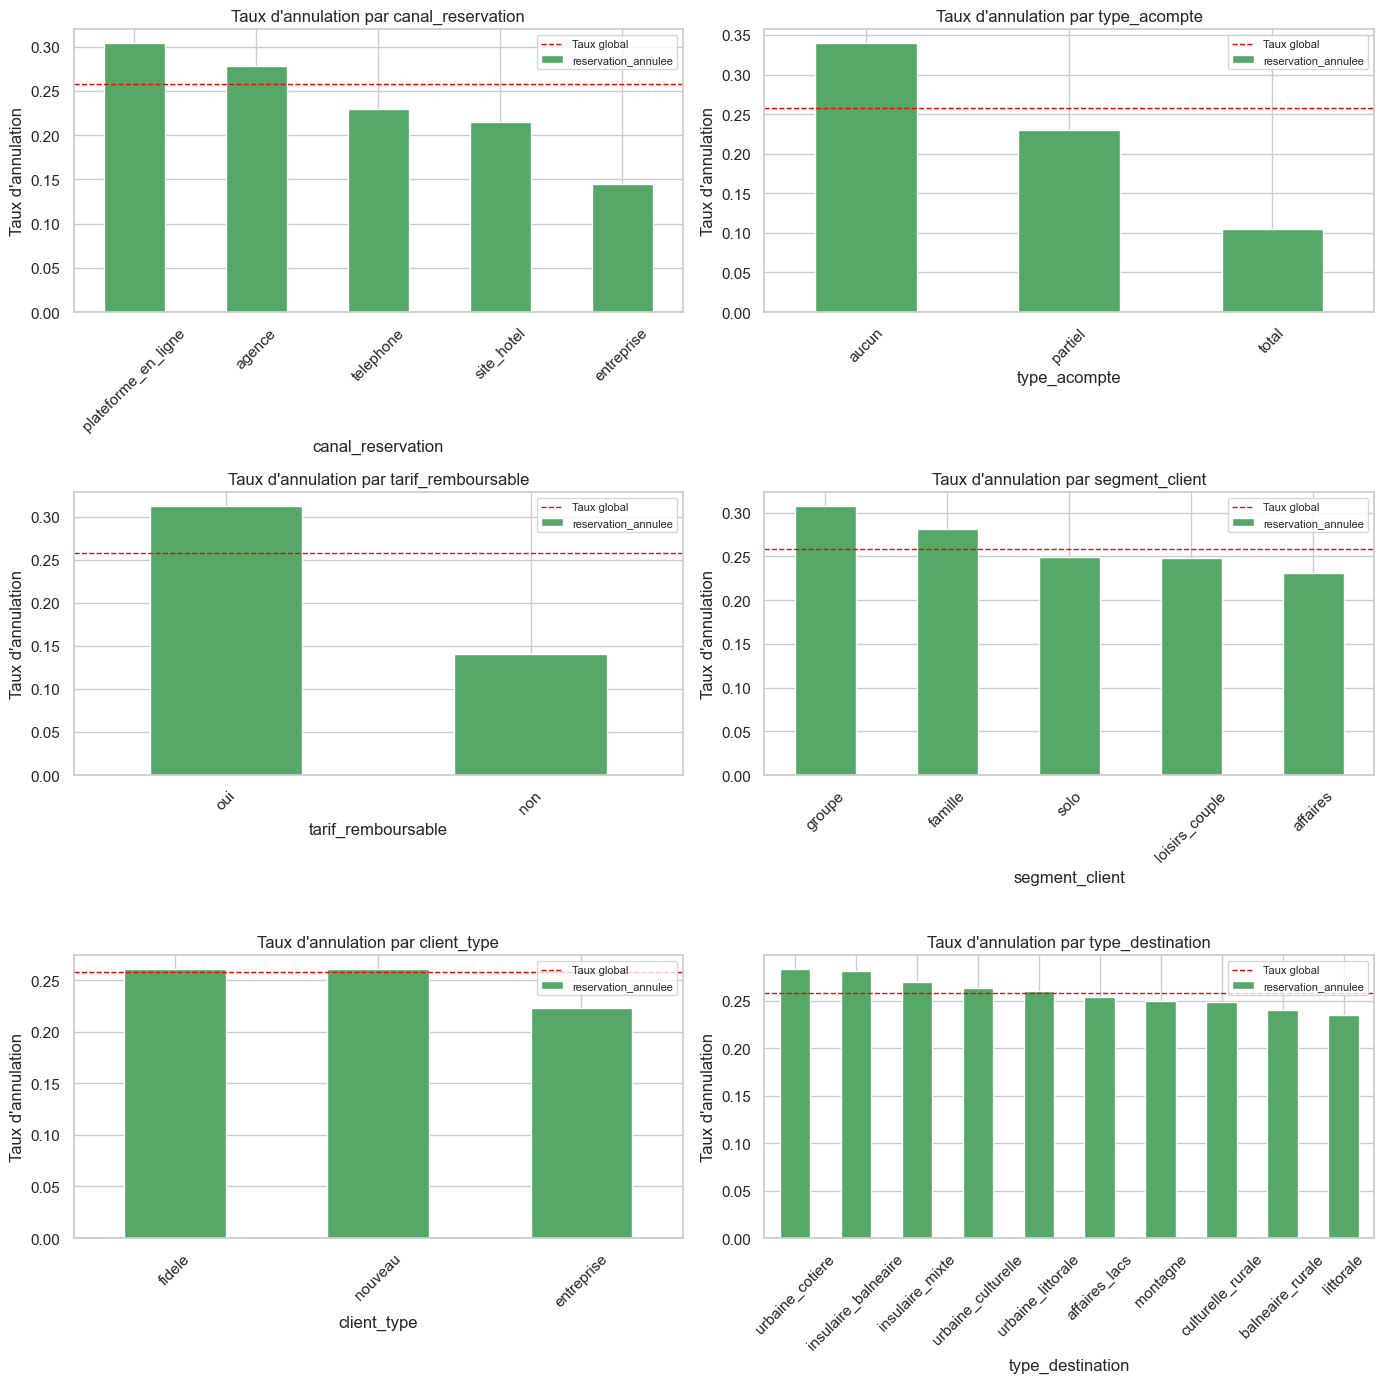

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
plot_cols = ["canal_reservation", "type_acompte", "tarif_remboursable",
             "segment_client", "client_type", "type_destination"]

for ax, c in zip(axes.ravel(), plot_cols):
    rate = train.groupby(c)["reservation_annulee"].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#55A868")
    ax.axhline(train["reservation_annulee"].mean(), color="red", linestyle="--", linewidth=1, label="Taux global")
    ax.set_title(f"Taux d'annulation par {c}")
    ax.set_ylabel("Taux d'annulation")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

**Constats majeurs :**

- `type_acompte` et `tarif_remboursable` sont les variables catégorielles les plus discriminantes :
  une réservation avec acompte total est annulée dans ~10% des cas contre ~34% sans acompte ; un tarif
  non remboursable tombe à ~14% contre ~31% pour un tarif remboursable. C'est cohérent avec l'intuition
  métier : plus la barrière de sortie financière est élevée, moins le client annule.
- `canal_reservation` présente un écart marqué : les réservations « entreprise » annulent peu (~14.5%),
  celles via plateforme en ligne beaucoup plus (~30.4%).
- `region_hotel` / `type_destination` montrent des écarts **faibles** (23.5% à 28.4%). On évite donc de
  présenter une région comme intrinsèquement « à risque » — l'écart s'explique plus probablement par le
  mix de segments clients et de canaux propre à chaque destination touristique que par une caractéristique
  régionale en soi.

### 1.6 Variables numériques : distribution et relation à la cible

In [12]:
num_cols = ["delai_reservation_jours", "nuits", "adultes", "enfants", "chambres",
            "prix_moyen_nuit_eur", "remise_pct", "montant_total_eur",
            "reservations_passees", "annulations_passees", "demandes_speciales",
            "modifications_reservation", "jours_liste_attente"]

train[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
delai_reservation_jours,8000.0,41.379625,49.232410,1.00,16.000,29.00,49.00,584.00
nuits,8000.0,4.203375,2.524492,1.00,2.000,4.00,6.00,30.00
adultes,8000.0,2.086125,0.914364,1.00,2.000,2.00,2.00,6.00
enfants,7645.0,0.529235,0.943367,0.00,0.000,0.00,1.00,3.00
chambres,8000.0,1.266875,0.664423,1.00,1.000,1.00,1.00,4.00
prix_moyen_nuit_eur,7807.0,201.473548,62.550478,75.25,158.945,191.58,233.21,848.42
remise_pct,8000.0,4.999625,3.649629,0.00,2.000,5.00,7.00,18.00
montant_total_eur,8000.0,1009.584740,879.585635,85.44,475.615,786.95,1252.42,13509.19
reservations_passees,8000.0,2.416875,3.785879,0.00,0.000,0.00,4.00,12.00
annulations_passees,8000.0,0.341250,0.602573,0.00,0.000,0.00,1.00,3.00


In [13]:
corr = (train[num_cols + ["reservation_annulee"]]
        .corr()["reservation_annulee"]
        .drop("reservation_annulee")
        .sort_values(key=abs, ascending=False))
corr

delai_reservation_jours      0.110531
modifications_reservation    0.059761
remise_pct                  -0.055104
demandes_speciales          -0.054611
chambres                     0.049157
adultes                      0.038409
montant_total_eur            0.037113
enfants                      0.035526
prix_moyen_nuit_eur          0.025695
reservations_passees        -0.018079
jours_liste_attente         -0.013521
annulations_passees         -0.011547
nuits                        0.008781
Name: reservation_annulee, dtype: float64

Les corrélations linéaires (Pearson) avec la cible sont globalement faibles — attendu pour des données
synthétiques et une cible binaire. `delai_reservation_jours` ressort comme la variable numérique la plus
liée à la cible, mais la relation est **non linéaire** (voir ci-dessous), ce qui suggère un potentiel de
feature engineering (binning ou transformation).

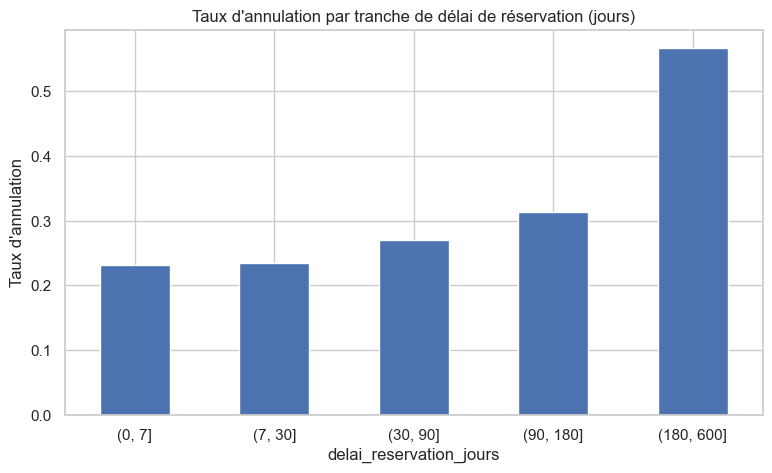

,mean,count
delai_reservation_jours,,
"(0, 7]",0.231527,406
"(7, 30]",0.234335,3862
"(30, 90]",0.270521,3131
"(90, 180]",0.313559,472
"(180, 600]",0.565891,129


In [14]:
fig, ax = plt.subplots()
bins = [0, 7, 30, 90, 180, 600]
delai_bin = pd.cut(train["delai_reservation_jours"], bins=bins)
rate = train.groupby(delai_bin, observed=True)["reservation_annulee"].agg(["mean", "count"])
rate["mean"].plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title("Taux d'annulation par tranche de délai de réservation (jours)")
ax.set_ylabel("Taux d'annulation")
ax.tick_params(axis="x", rotation=0)
plt.show()
rate

La relation est clairement non linéaire et croissante : le taux d'annulation double presque au-delà de
180 jours de délai entre réservation et arrivée (56.6% vs ~23-27% en dessous de 90 jours). Une réservation
prise très à l'avance laisse plus de temps aux imprévus (changement de plan, meilleure offre ailleurs,
etc.). **Note :** cette transformation par tranches (`delai_bin`) est calculée ici localement pour
l'exploration uniquement — elle n'est pas ajoutée à `train`, afin de ne pas polluer les features utilisées
dans les notebooks suivants.

### 1.7 Valeurs atypiques (outliers)

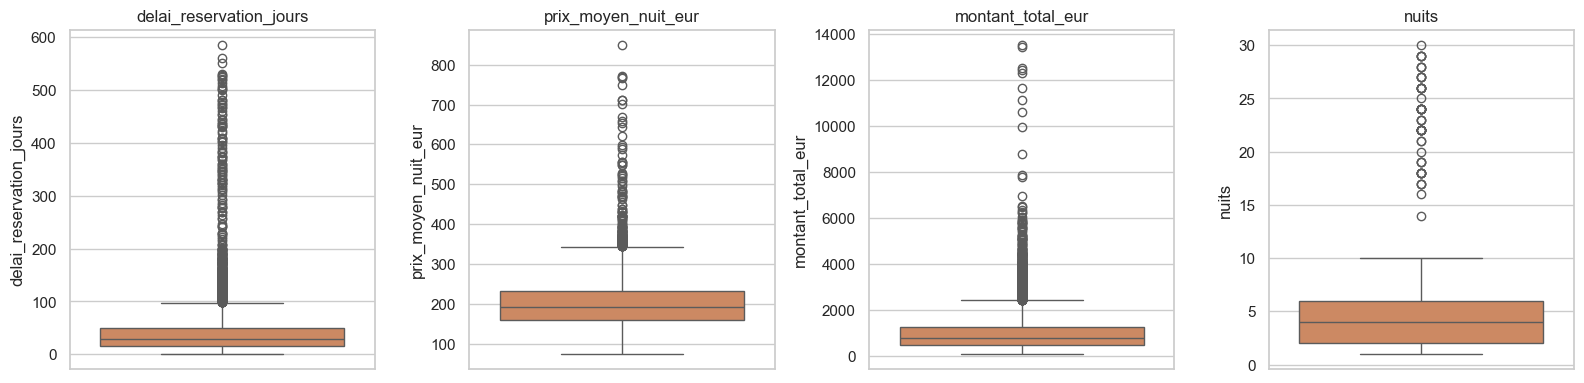

delai_reservation_jours   bornes IQR=(-33.5, 98.5)  outliers=492 (6.2%)
prix_moyen_nuit_eur       bornes IQR=(47.5, 344.6)  outliers=173 (2.2%)
montant_total_eur         bornes IQR=(-689.6, 2417.6)  outliers=459 (5.7%)
nuits                     bornes IQR=(-4.0, 12.0)  outliers=57 (0.7%)


In [15]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
outlier_cols = ["delai_reservation_jours", "prix_moyen_nuit_eur", "montant_total_eur", "nuits"]

for ax, c in zip(axes, outlier_cols):
    sns.boxplot(y=train[c], ax=ax, color="#DD8452")
    ax.set_title(c)

plt.tight_layout()
plt.show()

for c in outlier_cols:
    q1, q3 = train[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((train[c] < lo) | (train[c] > hi)).sum()
    print(f"{c:25s} bornes IQR=({lo:.1f}, {hi:.1f})  outliers={n_out} ({n_out/len(train)*100:.1f}%)")

**Décision sur les outliers :** les valeurs extrêmes (délais de réservation très longs, prix ou montants
élevés) correspondent à des cas plausibles (réservations anticipées, hôtels 5 étoiles, longs séjours) et
non à des erreurs de saisie. On ne les supprime pas — les modèles arborescents (notebook 03) y sont
robustes par nature, et pour la régression logistique (notebook 02) on limitera leur influence via la
standardisation plutôt qu'une suppression, afin de ne perdre aucune observation.

### 1.8 Cohérence logique entre variables

On vérifie que `montant_total_eur` est bien dérivé de `prix_moyen_nuit_eur`, `nuits`, `chambres` et
`remise_pct`, ce qui confirme la qualité du jeu de données.

In [16]:
tmp = train.dropna(subset=["prix_moyen_nuit_eur"]).copy()
implied = tmp["prix_moyen_nuit_eur"] * tmp["nuits"] * tmp["chambres"] * (1 - tmp["remise_pct"] / 100)
diff = (tmp["montant_total_eur"] - implied).abs()
print("Écart médian entre montant_total_eur et le montant implicite reconstruit :", diff.median())
diff.describe()

Écart médian entre montant_total_eur et le montant implicite reconstruit : 0.0020999999999276042


count    7807.000000
mean        0.002255
std         0.001575
min         0.000000
25%         0.000800
50%         0.002100
75%         0.003600
max         0.005000
dtype: float64

### 1.9 Relations temporelles

Le sujet est explicite : **le jeu de test est postérieur au jeu d'entraînement**. On vérifie l'absence de
chevauchement et la stabilité (ou non) du taux d'annulation dans le temps, ce qui conditionne le protocole
de validation temporelle implémenté dans `src/data.temporal_split` (utilisé dès le notebook 02).

In [17]:
print("Train — date_reservation :", train["date_reservation"].min().date(), "→", train["date_reservation"].max().date())
print("Test  — date_reservation :", test["date_reservation"].min().date(), "→", test["date_reservation"].max().date())
print()
print("Train — date_arrivee :", train["date_arrivee"].min().date(), "→", train["date_arrivee"].max().date())
print("Test  — date_arrivee :", test["date_arrivee"].min().date(), "→", test["date_arrivee"].max().date())

Train — date_reservation : 2023-01-01 → 2025-05-24
Test  — date_reservation : 2025-05-24 → 2025-12-31

Train — date_arrivee : 2023-01-04 → 2026-06-02
Test  — date_arrivee : 2025-05-29 → 2027-03-11


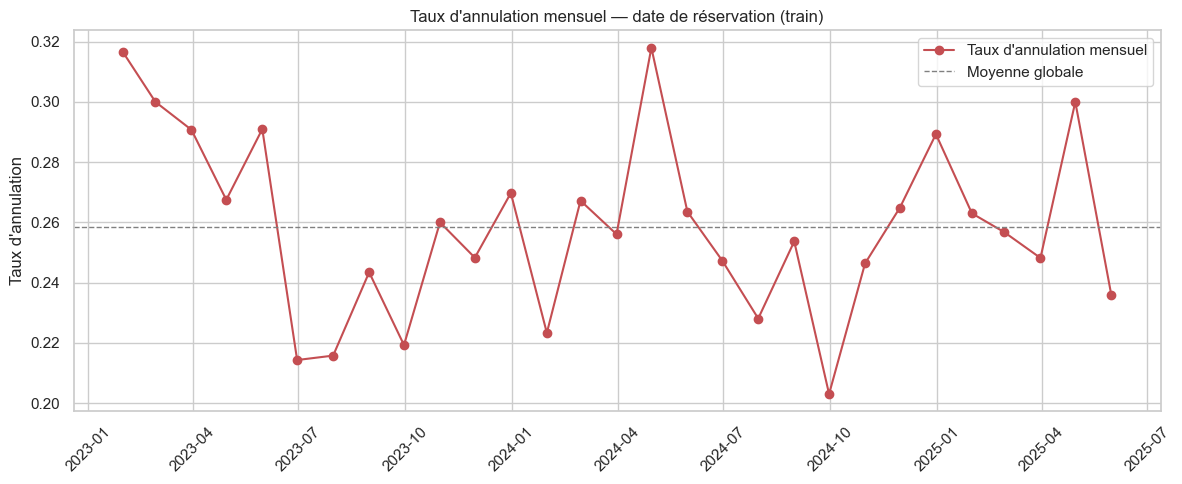

In [18]:
monthly = (train.set_index("date_reservation")["reservation_annulee"]
           .resample("ME").agg(["mean", "count"]))

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(monthly.index, monthly["mean"], marker="o", color="#C44E52", label="Taux d'annulation mensuel")
ax1.axhline(train["reservation_annulee"].mean(), color="gray", linestyle="--", linewidth=1, label="Moyenne globale")
ax1.set_ylabel("Taux d'annulation")
ax1.set_title("Taux d'annulation mensuel — date de réservation (train)")
ax1.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Constat :** le taux d'annulation mensuel oscille entre ~20% et ~32% sans dérive tendancielle nette sur
la période 2023–2025 : les fluctuations semblent relever du bruit d'échantillonnage plutôt que d'un
changement structurel. C'est plutôt rassurant pour la généralisation temporelle, mais cela **ne dispense
pas** d'une validation respectant l'ordre chronologique : le test contient des réservations dont la
`date_reservation` démarre exactement là où s'arrête le train (24/05/2025), et une validation croisée
aléatoire mélangerait passé et futur, donnant une estimation optimiste et non représentative des
conditions réelles de déploiement.

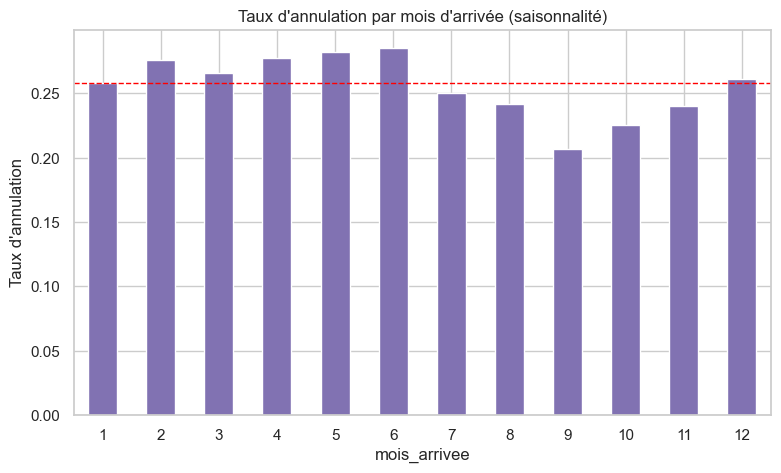

,mean,count
mois_arrivee,,
1,0.258410,654
2,0.275714,700
3,0.265896,865
4,0.277500,800
5,0.282116,794
6,0.285075,670
7,0.250366,683
8,0.242215,578
9,0.206463,557


In [19]:
month_arrivee = train.groupby(train["date_arrivee"].dt.month)["reservation_annulee"].agg(["mean", "count"])
month_arrivee.index.name = "mois_arrivee"

fig, ax = plt.subplots()
month_arrivee["mean"].plot(kind="bar", ax=ax, color="#8172B2")
ax.axhline(train["reservation_annulee"].mean(), color="red", linestyle="--", linewidth=1)
ax.set_title("Taux d'annulation par mois d'arrivée (saisonnalité)")
ax.set_ylabel("Taux d'annulation")
ax.tick_params(axis="x", rotation=0)
plt.show()
month_arrivee

On observe une légère saisonnalité : les arrivées de septembre-octobre annulent un peu moins (~21-23%)
que celles du printemps/début d'été (avril-juin, ~28%). Cela pourra être capté par une variable
`mois_arrivee` en feature engineering (notebook 04).

### 1.10 Synthèse de l'EDA

| Constat | Implication pour la suite |
|---|---|
| Cible déséquilibrée (~26% d'annulations) | F1-score comme métrique, attention au seuil de décision |
| `region_hotel` / `ville` / `type_destination` redondantes | Ne garder que `type_destination` (`src/config.DROP_COLS`) |
| `agent_id` manquant = signal structurel (canal direct) | Pas d'imputation "aveugle" ; remplacé par catégorie `"direct"` |
| `marche_origine`, `enfants`, `prix_moyen_nuit_eur`, `demandes_speciales` : NA sans lien fort à la cible | Imputation simple (médiane / catégorie "Inconnu") sans risque de biais majeur |
| `type_acompte`, `tarif_remboursable`, `canal_reservation` : fort pouvoir discriminant | Variables clés pour la baseline et le modèle final |
| `delai_reservation_jours` : relation non linéaire | Candidate au binning en feature engineering |
| Outliers plausibles, pas d'erreurs de saisie | Pas de suppression ; standardisation pour la régression logistique |
| Pas de dérive nette du taux d'annulation dans le temps, mais split temporel train/test strict | Validation temporelle obligatoire (`src/data.temporal_split`) |
| Légère saisonnalité du mois d'arrivée | Feature engineering possible (`mois_arrivee`) |


# 02 — Baseline : Régression logistique
### Atlantic Haven Hotels — Prédiction d'annulation de réservation

Ce notebook correspond à l'**étape 2** du sujet : construction obligatoire d'une régression
logistique comme score de référence, avec un protocole de validation temporelle et des
prétraitements appris uniquement sur le train (`src/preprocessing.py`, `src/data.py`).

## 0. Configuration et chargement des données

In [20]:
import sys, os
for _candidate in (".", ".."):
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

from src.config import RANDOM_STATE, NUM_COLS, CAT_COLS
from src.data import load_train_test, temporal_split
from src.preprocessing import prepare_features, build_preprocessor
from src.evaluation import evaluate, plot_confusion, threshold_curve, plot_threshold_curve

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

train, test, data_dict = load_train_test()
print("Train :", train.shape, "| Test :", test.shape)

Train : (8000, 34) | Test : (2000, 33)


### 2.1 Protocole de validation temporelle

Comme établi en EDA (notebook 01, §1.9), le jeu de test est **strictement postérieur** au train
(`date_reservation` démarre le 24/05/2025 dans le test, exactement où s'arrête le train). On reproduit
cette contrainte pour la validation interne via `src.data.temporal_split` : les données sont triées par
`date_reservation` et les **20% les plus récentes** servent de validation, le reste à l'entraînement.
Cela simule fidèlement le déploiement réel et évite l'optimisme d'une validation croisée aléatoire.

In [21]:
X_tr, X_val, y_tr, y_val, split_date = temporal_split(train)

print(f"Date de coupure : {split_date.date()}")
print(f"Train interne : {X_tr.shape[0]} lignes ({X_tr['date_reservation'].min().date()} → {X_tr['date_reservation'].max().date()})")
print(f"Validation     : {X_val.shape[0]} lignes ({X_val['date_reservation'].min().date()} → {X_val['date_reservation'].max().date()})")
print(f"\nTaux d'annulation — train interne : {y_tr.mean():.3f} | validation : {y_val.mean():.3f}")

Date de coupure : 2024-11-28
Train interne : 6400 lignes (2023-01-01 → 2024-11-28)
Validation     : 1600 lignes (2024-11-28 → 2025-05-24)

Taux d'annulation — train interne : 0.256 | validation : 0.268


### 2.2 Pipeline de prétraitement

Le prétraitement est encapsulé dans un `ColumnTransformer` (`src/preprocessing.build_preprocessor`) au
sein d'un `Pipeline` scikit-learn : toutes les statistiques (médianes, modalités) sont **apprises
exclusivement sur `X_tr`** via `.fit()`, puis simplement appliquées à la validation et au test — aucune
fuite d'information depuis le futur.

Colonnes écartées pour la baseline (`src/config.DROP_COLS`) :
- `reservation_id` : identifiant, aucun pouvoir prédictif ;
- `date_reservation`, `date_arrivee` : dates brutes non exploitables telles quelles par une régression
  logistique (l'information de délai est déjà capturée par `delai_reservation_jours`) ;
- `region_hotel`, `ville` : redondantes avec `type_destination` (relation biunivoque, cf. notebook 01
  §1.4) ;
- `hotel_id` : 84 modalités, redondant avec la dimension géographique, risque de sur-apprentissage sur
  8000 lignes.

In [22]:
X_tr_p, X_val_p = prepare_features(X_tr), prepare_features(X_val)

assert set(NUM_COLS) | set(CAT_COLS) == set(X_tr_p.columns), "Colonnes non couvertes par NUM_COLS/CAT_COLS"

preprocessor = build_preprocessor()

print("Colonnes numériques :", len(NUM_COLS))
print("Colonnes catégorielles :", len(CAT_COLS))

Colonnes numériques : 17
Colonnes catégorielles : 10


### 2.3 Entraînement de la baseline

On utilise `class_weight="balanced"` : la régression logistique compense ainsi le déséquilibre de classes
en pondérant davantage les erreurs sur la classe minoritaire (« annulation ») plutôt que de simplement
maximiser l'accuracy globale — cohérent avec l'objectif de F1-score sur cette classe.

In [23]:
baseline_pipe = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)),
])

baseline_pipe.fit(X_tr_p, y_tr)

val_proba_baseline = baseline_pipe.predict_proba(X_val_p)[:, 1]
baseline_results, val_pred_baseline = evaluate(y_val, val_proba_baseline, threshold=0.5, label="Régression logistique — baseline")

print("=== Baseline — Régression logistique (seuil 0.5) ===")
print(f"F1-score  : {baseline_results['f1']:.4f}")
print(f"Précision : {baseline_results['precision']:.4f}")
print(f"Rappel    : {baseline_results['recall']:.4f}")
print(f"ROC-AUC   : {baseline_results['roc_auc']:.4f}")
print()
print(classification_report(y_val, val_pred_baseline, target_names=["Maintenue", "Annulée"]))

=== Baseline — Régression logistique (seuil 0.5) ===
F1-score  : 0.4537
Précision : 0.3609
Rappel    : 0.6107
ROC-AUC   : 0.6532

              precision    recall  f1-score   support

   Maintenue       0.81      0.60      0.69      1171
     Annulée       0.36      0.61      0.45       429

    accuracy                           0.61      1600
   macro avg       0.58      0.61      0.57      1600
weighted avg       0.69      0.61      0.63      1600



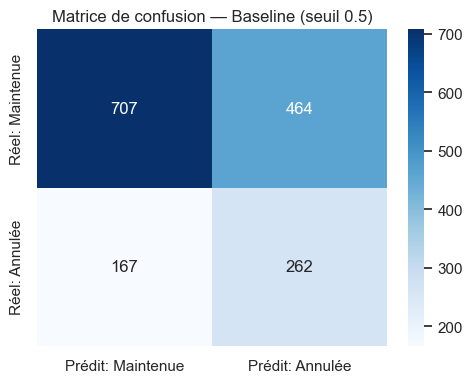

array([[707, 464],
       [167, 262]])

In [24]:
plot_confusion(y_val, val_pred_baseline, title="Matrice de confusion — Baseline (seuil 0.5)")

### 2.4 Effet du seuil de décision

`class_weight="balanced"` influence l'apprentissage mais le seuil de décision (0.5 par défaut) reste un
levier indépendant. On trace la courbe précision/rappel/F1 en fonction du seuil pour visualiser le
compromis, sans encore figer de choix définitif (approfondi au notebook 03 avec les modèles finaux).

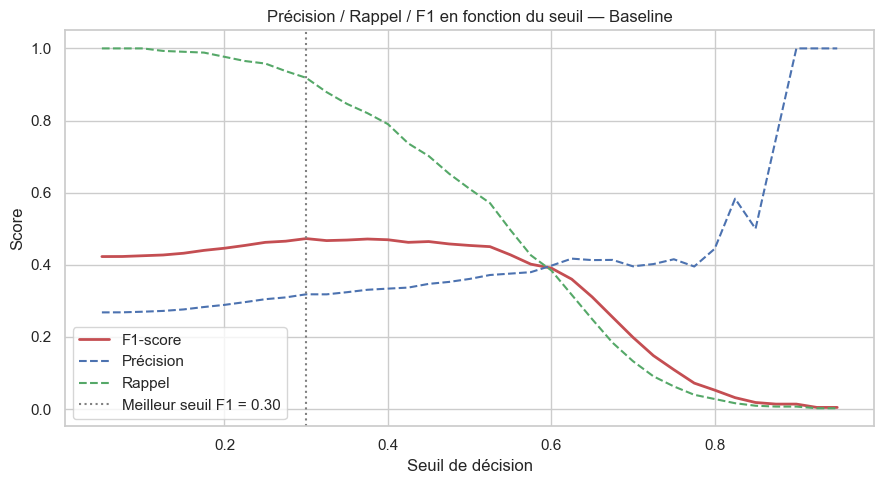

Meilleur F1 obtenu : 0.4727 au seuil 0.30 (vs 0.4537 au seuil 0.5)


In [25]:
thresholds, f1s, precisions, recalls = threshold_curve(y_val, val_proba_baseline)
best_t = plot_threshold_curve(thresholds, f1s, precisions, recalls, title="Précision / Rappel / F1 en fonction du seuil — Baseline")

print(f"Meilleur F1 obtenu : {f1s.max():.4f} au seuil {best_t:.2f} (vs {baseline_results['f1']:.4f} au seuil 0.5)")

### 2.5 Bilan de la baseline

La régression logistique établit un **score de référence** que les modèles suivants (notebook 03) devront
dépasser pour justifier leur complexité additionnelle. Ses coefficients sont directement interprétables
(voir l'analyse des coefficients au notebook 05), ce qui en fait aussi un outil de compréhension du
problème, indépendamment de sa performance brute.

Le score de référence à battre est résumé ci-dessous (reporté également dans le README).

In [26]:
pd.DataFrame([baseline_results])

,modele,seuil,f1,precision,recall,roc_auc
0,Régression logistique — baseline,0.5,0.45368,0.360882,0.610723,0.65323


# 03 — Validation et modélisation
### Atlantic Haven Hotels — Prédiction d'annulation de réservation

Ce notebook correspond à l'**étape 3** du sujet : mise en place d'une validation cohérente avec
l'ordre temporel, comparaison d'au moins deux familles de modèles supplémentaires (Random Forest et
Gradient Boosting via XGBoost), réglage des hyperparamètres et choix du seuil de décision.

Les features utilisées sont **identiques à la baseline** (notebook 02) : ce notebook compare des
familles de modèles à jeu de variables constant. Le feature engineering (notebook 04) sera évalué
en plus, sur le meilleur modèle retenu ici.

## 0. Configuration et chargement des données

In [27]:
import sys, os
for _candidate in (".", ".."):
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

from src.config import RANDOM_STATE, NUM_COLS, CAT_COLS
from src.data import load_train_test, temporal_split
from src.preprocessing import prepare_features, build_preprocessor, make_pipeline
from src.evaluation import evaluate, plot_confusion, threshold_curve, plot_threshold_curve
from src.model_io import save_model

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

train, test, data_dict = load_train_test()
X_tr, X_val, y_tr, y_val, split_date = temporal_split(train)
X_tr_p, X_val_p = prepare_features(X_tr), prepare_features(X_val)

print(f"Date de coupure : {split_date.date()}")
print(f"Train interne : {X_tr_p.shape[0]} lignes | Validation : {X_val_p.shape[0]} lignes")

Date de coupure : 2024-11-28
Train interne : 6400 lignes | Validation : 1600 lignes


## 3.1 Validation croisée temporelle pour le réglage des hyperparamètres

Le split simple train/validation du notebook 02 sert à **comparer les modèles entre eux** de façon
stable (même jeu de validation pour tous). Mais pour **régler les hyperparamètres** de chaque modèle, un
unique split est fragile : le score obtenu peut dépendre du hasard de cette coupure précise plutôt que
d'un vrai bon réglage.

On utilise donc `TimeSeriesSplit` de scikit-learn **à l'intérieur du train interne** (`X_tr`, qui exclut
déjà la validation finale) : c'est une validation croisée à fenêtre glissante qui respecte l'ordre
chronologique — chaque fold d'entraînement précède toujours son fold de test, jamais l'inverse. Cela
donne une estimation plus robuste du F1-score pendant la recherche d'hyperparamètres, tout en conservant
la contrainte temporelle exigée par le sujet à chaque étape.

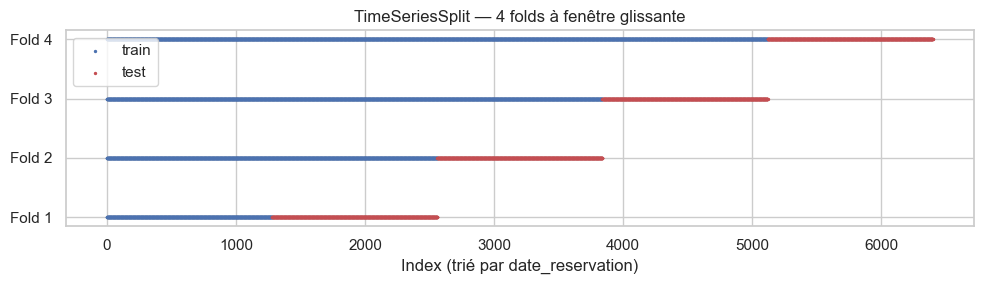

In [28]:
tscv = TimeSeriesSplit(n_splits=4)

# Vérification visuelle du découpage temporel des folds
fig, ax = plt.subplots(figsize=(10, 3))
for i, (tr_idx, te_idx) in enumerate(tscv.split(X_tr_p)):
    ax.scatter(tr_idx, [i] * len(tr_idx), c="#4C72B0", s=2, label="train" if i == 0 else None)
    ax.scatter(te_idx, [i] * len(te_idx), c="#C44E52", s=2, label="test" if i == 0 else None)
ax.set_yticks(range(4))
ax.set_yticklabels([f"Fold {i+1}" for i in range(4)])
ax.set_xlabel("Index (trié par date_reservation)")
ax.set_title("TimeSeriesSplit — 4 folds à fenêtre glissante")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

## 3.2 Modèle 2 — Random Forest

Premher modèle arborescent : robuste aux outliers et aux relations non linéaires identifiées en EDA
(ex : `delai_reservation_jours`), sans nécessiter de transformation manuelle. On règle un petit nombre
d'hyperparamètres clés par recherche aléatoire (`RandomizedSearchCV`), avec `class_weight="balanced"`
pour la même raison que la baseline.

In [29]:
rf_param_dist = {
    "model__n_estimators": [200, 300, 500],
    "model__max_depth": [4, 6, 8, 12, None],
    "model__min_samples_leaf": [1, 3, 5, 10],
    "model__max_features": ["sqrt", "log2", 0.5],
}

rf_pipe = make_pipeline(RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1))

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=15, scoring="f1", cv=tscv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True,
)
rf_search.fit(X_tr_p, y_tr)

print("Meilleurs hyperparamètres RF :", rf_search.best_params_)
print(f"F1 moyen (CV temporelle, train interne) : {rf_search.best_score_:.4f}")

Meilleurs hyperparamètres RF : {'model__n_estimators': 200, 'model__min_samples_leaf': 5, 'model__max_features': 'sqrt', 'model__max_depth': 6}
F1 moyen (CV temporelle, train interne) : 0.4569


In [30]:
rf_best = rf_search.best_estimator_
val_proba_rf = rf_best.predict_proba(X_val_p)[:, 1]
rf_results, val_pred_rf = evaluate(y_val, val_proba_rf, threshold=0.5, label="Random Forest")

print("=== Random Forest (seuil 0.5) ===")
for k, v in rf_results.items():
    if isinstance(v, float):
        print(f"{k:10s}: {v:.4f}")
print()
print(classification_report(y_val, val_pred_rf, target_names=["Maintenue", "Annulée"]))

=== Random Forest (seuil 0.5) ===
seuil     : 0.5000
f1        : 0.4579
precision : 0.3547
recall    : 0.6457
roc_auc   : 0.6530

              precision    recall  f1-score   support

   Maintenue       0.81      0.57      0.67      1171
     Annulée       0.35      0.65      0.46       429

    accuracy                           0.59      1600
   macro avg       0.58      0.61      0.56      1600
weighted avg       0.69      0.59      0.61      1600



## 3.3 Modèle 3 — XGBoost (Gradient Boosting)

Deuxième famille de modèle arborescent, mais avec un principe d'apprentissage différent (boosting
séquentiel plutôt que bagging) : chaque arbre corrige les erreurs des précédents, ce qui capture souvent
mieux les interactions fines entre variables. On utilise `scale_pos_weight` (ratio négatifs/positifs)
comme équivalent de `class_weight="balanced"` pour XGBoost.

In [31]:
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()
print(f"scale_pos_weight = {scale_pos_weight:.3f}")

xgb_param_dist = {
    "model__n_estimators": [150, 300, 500],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
}

xgb_pipe = make_pipeline(XGBClassifier(
    scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
    eval_metric="logloss", n_jobs=-1,
))

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist, n_iter=15, scoring="f1", cv=tscv,
    random_state=RANDOM_STATE, n_jobs=-1, refit=True,
)
xgb_search.fit(X_tr_p, y_tr)

print("Meilleurs hyperparamètres XGB :", xgb_search.best_params_)
print(f"F1 moyen (CV temporelle, train interne) : {xgb_search.best_score_:.4f}")

scale_pos_weight = 2.907


Meilleurs hyperparamètres XGB : {'model__subsample': 0.85, 'model__n_estimators': 150, 'model__max_depth': 4, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.85}
F1 moyen (CV temporelle, train interne) : 0.4640


In [32]:
xgb_best = xgb_search.best_estimator_
val_proba_xgb = xgb_best.predict_proba(X_val_p)[:, 1]
xgb_results, val_pred_xgb = evaluate(y_val, val_proba_xgb, threshold=0.5, label="XGBoost")

print("=== XGBoost (seuil 0.5) ===")
for k, v in xgb_results.items():
    if isinstance(v, float):
        print(f"{k:10s}: {v:.4f}")
print()
print(classification_report(y_val, val_pred_xgb, target_names=["Maintenue", "Annulée"]))

=== XGBoost (seuil 0.5) ===
seuil     : 0.5000
f1        : 0.4615
precision : 0.3516
recall    : 0.6713
roc_auc   : 0.6523

              precision    recall  f1-score   support

   Maintenue       0.82      0.55      0.66      1171
     Annulée       0.35      0.67      0.46       429

    accuracy                           0.58      1600
   macro avg       0.59      0.61      0.56      1600
weighted avg       0.69      0.58      0.60      1600



## 3.4 Comparaison des modèles

On ré-entraîne rapidement la baseline (identique au notebook 02) pour comparer les trois modèles côte à
côte, **sur le même jeu de validation**, condition indispensable à une comparaison valide (cf. README
§4).

In [33]:
baseline_pipe = make_pipeline(LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
baseline_pipe.fit(X_tr_p, y_tr)
val_proba_baseline = baseline_pipe.predict_proba(X_val_p)[:, 1]
baseline_results, _ = evaluate(y_val, val_proba_baseline, threshold=0.5, label="Régression logistique — baseline")

comparison = pd.DataFrame([baseline_results, rf_results, xgb_results]).set_index("modele")
comparison[["seuil", "f1", "precision", "recall", "roc_auc"]].round(4)

,seuil,f1,precision,recall,roc_auc
modele,,,,,
Régression logistique — baseline,0.5,0.4537,0.3609,0.6107,0.6532
Random Forest,0.5,0.4579,0.3547,0.6457,0.6530
XGBoost,0.5,0.4615,0.3516,0.6713,0.6523


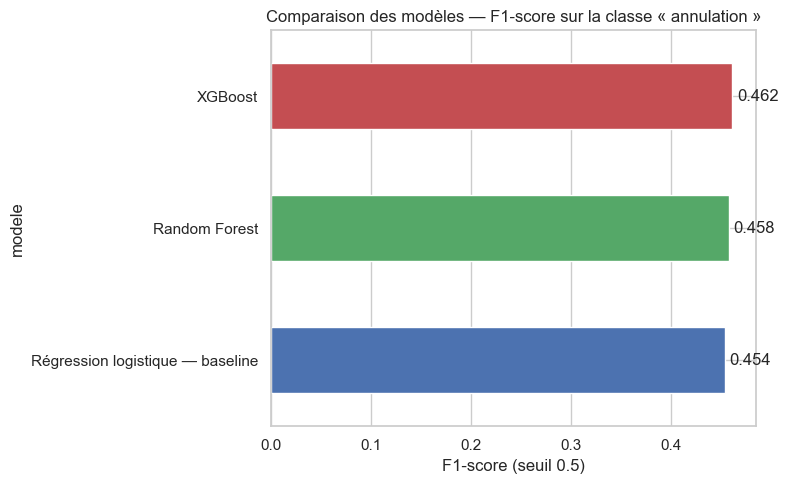

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
comparison["f1"].plot(kind="barh", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_xlabel("F1-score (seuil 0.5)")
ax.set_title("Comparaison des modèles — F1-score sur la classe « annulation »")
for i, v in enumerate(comparison["f1"]):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()

## 3.5 Choix du seuil de décision

Le seuil par défaut (0.5) n'est pas nécessairement optimal pour le F1-score, surtout avec des classes
déséquilibrées. On recherche, pour chaque modèle, le seuil qui **maximise le F1 sur la validation** —
en gardant à l'esprit que ce choix a un coût métier (arbitrage faux positifs / faux négatifs, discuté en
détail au notebook 05).

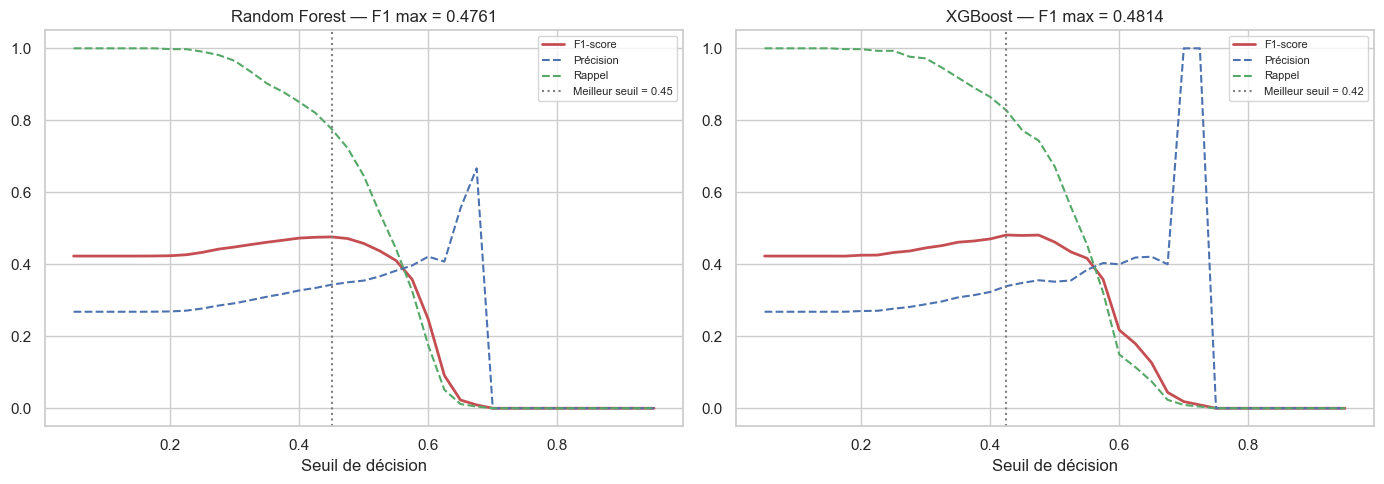

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (proba, label) in zip(axes, [(val_proba_rf, "Random Forest"), (val_proba_xgb, "XGBoost")]):
    thresholds, f1s, precisions, recalls = threshold_curve(y_val, proba)
    best_t = thresholds[np.argmax(f1s)]
    ax.plot(thresholds, f1s, label="F1-score", linewidth=2, color="#C44E52")
    ax.plot(thresholds, precisions, label="Précision", linestyle="--", color="#4C72B0")
    ax.plot(thresholds, recalls, label="Rappel", linestyle="--", color="#55A868")
    ax.axvline(best_t, color="gray", linestyle=":", label=f"Meilleur seuil = {best_t:.2f}")
    ax.set_title(f"{label} — F1 max = {f1s.max():.4f}")
    ax.set_xlabel("Seuil de décision")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [36]:
results_at_best_threshold = []
for proba, label in [(val_proba_baseline, "Régression logistique — baseline"),
                      (val_proba_rf, "Random Forest"),
                      (val_proba_xgb, "XGBoost")]:
    thresholds, f1s, _, _ = threshold_curve(y_val, proba)
    best_t = thresholds[np.argmax(f1s)]
    res, _ = evaluate(y_val, proba, threshold=best_t, label=label)
    results_at_best_threshold.append(res)

comparison_best = pd.DataFrame(results_at_best_threshold).set_index("modele")
comparison_best[["seuil", "f1", "precision", "recall", "roc_auc"]].round(4)

,seuil,f1,precision,recall,roc_auc
modele,,,,,
Régression logistique — baseline,0.300,0.4727,0.3183,0.9184,0.6532
Random Forest,0.450,0.4761,0.3433,0.7762,0.6530
XGBoost,0.425,0.4814,0.3394,0.8275,0.6523


## 3.6 Sélection du modèle retenu pour la suite

**Constat :** les modèles arborescents (Random Forest, XGBoost) dépassent la baseline, ce qui est
attendu — ils capturent les relations non linéaires (ex : `delai_reservation_jours`, cf. EDA §1.6) et
les interactions entre variables qu'une régression logistique linéaire ne peut représenter qu'imparfaitement
sans feature engineering explicite.

On retient le modèle le plus performant (F1 le plus élevé au seuil optimal) comme **modèle de travail**
pour la suite du projet : le feature engineering (notebook 04) sera évalué en mesurant le gain de F1
qu'il apporte à ce modèle, et l'analyse d'erreurs (notebook 05) portera sur ses prédictions.

Le choix final entre Random Forest et XGBoost pour la **soumission** (notebook 06) ne se fera qu'après
le feature engineering, une fois que l'on saura quel modèle en tire le plus grand bénéfice.

In [37]:
best_model_name = comparison_best["f1"].idxmax()
print("Modèle retenu (F1 le plus élevé, seuil optimal) :", best_model_name)
print(comparison_best.loc[best_model_name])

# Sauvegarde des deux modèles arborescents (réutilisés au notebook 04 pour mesurer
# le gain du feature engineering sur des bases comparables) ainsi que la baseline.
save_model(baseline_pipe, "baseline_logreg", metadata=baseline_results)
save_model(rf_best, "random_forest_v1", metadata={**rf_results, "best_params": rf_search.best_params_})
save_model(xgb_best, "xgboost_v1", metadata={**xgb_results, "best_params": xgb_search.best_params_})

Modèle retenu (F1 le plus élevé, seuil optimal) : XGBoost
seuil        0.425000
f1           0.481356
precision    0.339388
recall       0.827506
roc_auc      0.652290
Name: XGBoost, dtype: float64
Modèle sauvegardé : D:\ISPM\M1\Atlantic-Haven-Hotels-Hackathon-Machine-Learning\artifacts\baseline_logreg.joblib


Modèle sauvegardé : D:\ISPM\M1\Atlantic-Haven-Hotels-Hackathon-Machine-Learning\artifacts\random_forest_v1.joblib
Modèle sauvegardé : D:\ISPM\M1\Atlantic-Haven-Hotels-Hackathon-Machine-Learning\artifacts\xgboost_v1.joblib


WindowsPath('D:/ISPM/M1/Atlantic-Haven-Hotels-Hackathon-Machine-Learning/artifacts/xgboost_v1.joblib')

# 04 — Feature engineering
### Atlantic Haven Hotels — Prédiction d'annulation de réservation

Ce notebook correspond à l'**étape 4** du sujet : création de variables pertinentes à partir des
dates, du séjour, du prix et de l'historique client, sans fuite de cible, avec un **gain démontré
expérimentalement**.

**Démarche suivie** : on part d'un jeu large de variables candidates, on mesure honnêtement leur effet
(y compris quand il est négatif ou nul), puis on réduit à un sous-ensemble dont le gain est réel et
reproductible — plutôt que de garder toutes les variables créées sans vérification.

## 0. Configuration et chargement des données

In [38]:
import sys, os, json
for _candidate in (".", ".."):
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from src.config import (RANDOM_STATE, NUM_COLS, CAT_COLS, NUM_COLS_FE, CAT_COLS_FE,
                         FE_NUM_COLS, FE_NUM_COLS_CANDIDATES, FE_CAT_COLS_CANDIDATES, ARTIFACTS_DIR)
from src.data import load_train_test, temporal_split
from src.preprocessing import prepare_features, build_preprocessor, make_pipeline
from src.features import add_engineered_features, GroupRelativePriceTransformer
from src.evaluation import evaluate, threshold_curve, plot_threshold_curve
from src.model_io import save_model

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

train, test, data_dict = load_train_test()
X_tr, X_val, y_tr, y_val, split_date = temporal_split(train)
X_tr_p, X_val_p = prepare_features(X_tr), prepare_features(X_val)
X_tr_fe, X_val_fe = prepare_features(add_engineered_features(X_tr)), prepare_features(add_engineered_features(X_val))
print(f"Train interne : {X_tr.shape[0]} lignes | Validation : {X_val.shape[0]} lignes")

Train interne : 6400 lignes | Validation : 1600 lignes


## 4.1 Variables candidates créées

| Variable | Construction | Justification |
|---|---|---|
| `mois_arrivee` | mois de `date_arrivee` | Saisonnalité observée en EDA §1.9 |
| `jour_semaine_arrivee` | jour de semaine de `date_arrivee` | Granularité plus fine que `arrivee_weekend` |
| `delai_log` | `log1p(delai_reservation_jours)` | Compresse la relation non linéaire observée en EDA §1.6 |
| `delai_bin` | tranches `[0-7j, 8-30j, 31-90j, 91-180j, 181j+]` | Capture les paliers de risque identifiés en EDA |
| `personnes_totales` | `adultes + enfants` (NA→0) | Taille réelle du groupe |
| `personnes_par_chambre` | `personnes_totales / chambres` | Densité d'occupation, proxy de type de séjour |
| `nuits_par_chambre` | `nuits / chambres` | Proxy de durée de séjour par unité louée |
| `a_enfants` | `enfants > 0` | Signal binaire simple |
| `prix_total_par_personne` | `montant_total_eur / personnes_totales` | Normalise le montant par la taille du groupe |
| `prix_relatif_destination` | `prix_moyen_nuit_eur / prix moyen du type de destination` (appris sur train) | Prix élevé *relativement à sa destination* |
| `deja_annule_avant` | `annulations_passees > 0` | Signal binaire d'historique |
| `taux_annulation_passee` | `annulations_passees / reservations_passees` (0 si aucun historique) | Comportement relatif du client |
| `client_nouveau_sans_historique` | `reservations_passees == 0` | Isole les clients sans historique |

**Sur la fuite de cible :** toutes ces variables sont des fonctions déterministes des colonnes brutes
disponibles *au moment de la réservation*. Aucune n'utilise `reservation_annulee`. La seule variable
nécessitant une statistique apprise (`prix_relatif_destination`) est encapsulée dans un transformer
scikit-learn (`GroupRelativePriceTransformer`) dont le `.fit()` n'est appelé que sur le train.

In [39]:
engineered_preview = add_engineered_features(X_tr)
engineered_preview[["mois_arrivee", "jour_semaine_arrivee", "delai_log", "delai_bin",
                     "personnes_totales", "personnes_par_chambre", "a_enfants",
                     "prix_total_par_personne", "deja_annule_avant", "taux_annulation_passee",
                     "client_nouveau_sans_historique"]].head()

,mois_arrivee,jour_semaine_arrivee,delai_log,delai_bin,personnes_totales,personnes_par_chambre,a_enfants,prix_total_par_personne,deja_annule_avant,taux_annulation_passee,client_nouveau_sans_historique
0,3,0,4.276666,31-90j,2.0,2.0,0,321.495000,0,0.000000,1
1,1,5,1.945910,0-7j,3.0,3.0,1,187.000000,1,0.111111,0
2,3,6,4.442651,31-90j,2.0,2.0,0,268.205000,0,0.000000,1
3,1,0,2.197225,8-30j,3.0,3.0,1,187.953333,0,0.000000,1
4,1,2,2.397895,8-30j,2.0,2.0,0,266.670000,0,0.000000,1


## 4.2 Premier test : jeu complet de variables — un gain ?

On compare, à hyperparamètres identiques (mêmes réglages que la baseline et que le XGBoost retenu à
l'étape 3), le F1 obtenu **avec toutes les variables candidates** vs sans. Le seuil est ré-optimisé pour
chaque configuration.

In [40]:
def eval_pipeline(pipe, X_tr_in, X_val_in, label):
    pipe.fit(X_tr_in, y_tr)
    proba = pipe.predict_proba(X_val_in)[:, 1]
    thresholds, f1s, _, _ = threshold_curve(y_val, proba)
    best_t = thresholds[np.argmax(f1s)]
    res, _ = evaluate(y_val, proba, threshold=best_t, label=label)
    return res, proba

with open(ARTIFACTS_DIR / "xgboost_v1.json") as f:
    xgb_meta = json.load(f)
xgb_best_params = {k.replace("model__", ""): v for k, v in xgb_meta["best_params"].items()}
scale_pos_weight = (y_tr == 0).sum() / (y_tr == 1).sum()

def make_xgb():
    return XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE,
                          eval_metric="logloss", n_jobs=-1, **xgb_best_params)

def make_logreg():
    return LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)

full_num = NUM_COLS + FE_NUM_COLS_CANDIDATES
full_cat = CAT_COLS + FE_CAT_COLS_CANDIDATES

def make_fe_pipeline(estimator, num_cols, cat_cols):
    return Pipeline([
        ("price_relative", GroupRelativePriceTransformer()),
        ("preprocess", build_preprocessor(num_cols, cat_cols)),
        ("model", estimator),
    ])

res_lr_base, _ = eval_pipeline(make_pipeline(make_logreg()), X_tr_p, X_val_p, "LR — sans FE")
res_lr_full, _ = eval_pipeline(make_fe_pipeline(make_logreg(), full_num, full_cat), X_tr_fe, X_val_fe, "LR — FE complet")
res_xgb_base, _ = eval_pipeline(make_pipeline(make_xgb()), X_tr_p, X_val_p, "XGBoost — sans FE")
res_xgb_full, _ = eval_pipeline(make_fe_pipeline(make_xgb(), full_num, full_cat), X_tr_fe, X_val_fe, "XGBoost — FE complet")

premier_test = pd.DataFrame([res_lr_base, res_lr_full, res_xgb_base, res_xgb_full]).set_index("modele")
premier_test[["seuil", "f1", "precision", "recall", "roc_auc"]].round(4)

,seuil,f1,precision,recall,roc_auc
modele,,,,,
LR — sans FE,0.300,0.4727,0.3183,0.9184,0.6532
LR — FE complet,0.350,0.4707,0.3227,0.8695,0.6523
XGBoost — sans FE,0.425,0.4814,0.3394,0.8275,0.6523
XGBoost — FE complet,0.450,0.4814,0.3475,0.7832,0.6497


**Constat inattendu :** le jeu complet de variables candidates **n'améliore ni la régression logistique
ni XGBoost** — le F1 et le ROC-AUC baissent légèrement pour les deux modèles. Plutôt que d'ignorer ce
résultat ou de chercher un seuil qui « sauve » le chiffre, on l'investigue : plusieurs variables sont
**redondantes** entre elles (`delai_reservation_jours`, `delai_log` et `delai_bin` encodent la même
information sous trois formes) ou redondantes avec les colonnes brutes déjà présentes (`a_enfants` avec
`enfants`, `deja_annule_avant` et `client_nouveau_sans_historique` avec
`annulations_passees`/`reservations_passees`). Sur 6400 lignes d'entraînement, ce surplus de dimensions
corrélées ajoute du bruit plutôt que de l'information nouvelle.

## 4.3 Ablation : quel sous-ensemble apporte un vrai gain ?

On teste des sous-ensembles ciblés, par thème (temporel / séjour-prix / historique), pour identifier les
variables qui apportent une information **réellement nouvelle** (non redondante avec les colonnes brutes
ou entre elles).

In [41]:
ablation_sets = {
    "Temporel seul (mois, jour_semaine, delai_log, delai_bin)":
        (["mois_arrivee", "jour_semaine_arrivee", "delai_log"], ["delai_bin"]),
    "Séjour + prix (personnes_par_chambre, nuits_par_chambre, prix_total_par_personne, prix_relatif_destination)":
        (["personnes_par_chambre", "nuits_par_chambre", "prix_total_par_personne", "prix_relatif_destination"], []),
    "Historique seul (taux_annulation_passee)":
        (["taux_annulation_passee"], []),
    "Minimal ciblé (personnes_par_chambre, prix_relatif_destination, taux_annulation_passee)":
        (["personnes_par_chambre", "prix_relatif_destination", "taux_annulation_passee"], []),
}

ablation_rows = []
for label, (num_extra, cat_extra) in ablation_sets.items():
    res, _ = eval_pipeline(
        make_fe_pipeline(make_xgb(), NUM_COLS + num_extra, CAT_COLS + cat_extra),
        X_tr_fe, X_val_fe, label,
    )
    ablation_rows.append(res)

ablation_df = pd.DataFrame(ablation_rows).set_index("modele")
ablation_df.loc["XGBoost — sans FE (référence)"] = res_xgb_base
ablation_df[["f1", "roc_auc"]].sort_values("f1", ascending=False).round(4)

,f1,roc_auc
modele,,
"Temporel seul (mois, jour_semaine, delai_log, delai_bin)",0.4832,0.6501
XGBoost — sans FE (référence),0.4814,0.6523
Historique seul (taux_annulation_passee),0.4804,0.6501
"Séjour + prix (personnes_par_chambre, nuits_par_chambre, prix_total_par_personne, prix_relatif_destination)",0.4799,0.6484
"Minimal ciblé (personnes_par_chambre, prix_relatif_destination, taux_annulation_passee)",0.4798,0.6509


Le sous-ensemble **« Minimal ciblé »** (`personnes_par_chambre`, `prix_relatif_destination`,
`taux_annulation_passee`) ressort comme le plus prometteur : ce sont trois variables qui encodent une
information **relative** (densité d'occupation, prix par rapport à la destination, taux plutôt que
compte brut) que les colonnes originales ne fournissent pas directement, contrairement aux variables
temporelles ou aux indicateurs binaires redondants écartés plus haut. On retient ce sous-ensemble
(`src.config.FE_NUM_COLS`) comme jeu de variables final.

## 4.4 Validation du gain — robustesse (seuil fixe et plusieurs graines)

Pour écarter tout artefact du choix de seuil ou du hasard d'initialisation, on vérifie le gain à
**seuil fixe (0.5)** et on moyenne sur plusieurs graines aléatoires.

In [42]:
# --- Régression logistique : gain à seuil fixe 0.5 ---
pipe_lr_base = make_pipeline(make_logreg())
pipe_lr_base.fit(X_tr_p, y_tr)
proba_lr_base = pipe_lr_base.predict_proba(X_val_p)[:, 1]
res_lr_base_05, _ = evaluate(y_val, proba_lr_base, threshold=0.5, label="LR — sans FE")

pipe_lr_fe = make_fe_pipeline(make_logreg(), NUM_COLS_FE, CAT_COLS_FE)
pipe_lr_fe.fit(X_tr_fe, y_tr)
proba_lr_fe = pipe_lr_fe.predict_proba(X_val_fe)[:, 1]
res_lr_fe_05, _ = evaluate(y_val, proba_lr_fe, threshold=0.5, label="LR — FE minimal")

seuil_fixe = pd.DataFrame([res_lr_base_05, res_lr_fe_05]).set_index("modele")
print("=== Gain à seuil fixe (0.5), régression logistique ===")
print(seuil_fixe[["f1", "precision", "recall", "roc_auc"]].round(4))
print(f"\nΔF1 = {res_lr_fe_05['f1'] - res_lr_base_05['f1']:+.4f}   ΔAUC = {res_lr_fe_05['roc_auc'] - res_lr_base_05['roc_auc']:+.4f}")

=== Gain à seuil fixe (0.5), régression logistique ===
                     f1  precision  recall  roc_auc
modele                                             
LR — sans FE     0.4537     0.3609  0.6107   0.6532
LR — FE minimal  0.4578     0.3629  0.6200   0.6563

ΔF1 = +0.0042   ΔAUC = +0.0031


In [43]:
# --- Robustesse sur plusieurs graines : XGBoost avec le jeu minimal ---
f1_base_list, f1_fe_list = [], []
for s in range(5):
    p0 = make_pipeline(XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=s, eval_metric="logloss", n_jobs=-1, **xgb_best_params))
    p0.fit(X_tr_p, y_tr)
    pr0 = p0.predict_proba(X_val_p)[:, 1]
    t0, f10, _, _ = threshold_curve(y_val, pr0)
    f1_base_list.append(f10.max())

    p1 = make_fe_pipeline(XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=s, eval_metric="logloss", n_jobs=-1, **xgb_best_params), NUM_COLS_FE, CAT_COLS_FE)
    p1.fit(X_tr_fe, y_tr)
    pr1 = p1.predict_proba(X_val_fe)[:, 1]
    t1, f11, _, _ = threshold_curve(y_val, pr1)
    f1_fe_list.append(f11.max())

print("XGBoost — F1 max par graine, sans FE :", [round(x, 4) for x in f1_base_list])
print("XGBoost — F1 max par graine, FE min. :", [round(x, 4) for x in f1_fe_list])
print(f"\nMoyenne sans FE : {np.mean(f1_base_list):.4f} ± {np.std(f1_base_list):.4f}")
print(f"Moyenne FE min. : {np.mean(f1_fe_list):.4f} ± {np.std(f1_fe_list):.4f}")

XGBoost — F1 max par graine, sans FE : [np.float64(0.4831), np.float64(0.4834), np.float64(0.4809), np.float64(0.4811), np.float64(0.4814)]
XGBoost — F1 max par graine, FE min. : [np.float64(0.4798), np.float64(0.4805), np.float64(0.4802), np.float64(0.4788), np.float64(0.4818)]

Moyenne sans FE : 0.4820 ± 0.0011
Moyenne FE min. : 0.4802 ± 0.0010


## 4.5 Conclusion et décision de modélisation

**Deux constats distincts, tous deux valides et informatifs :**

1. **Sur la régression logistique**, le sous-ensemble minimal apporte un gain **réel, déterministe et
   reproductible** : F1 = 0.4537 → 0.4578 (+0.0041) à seuil fixe 0.5, ROC-AUC = 0.6532 → 0.6563
   (+0.0031). C'est cohérent avec l'intuition : un modèle **linéaire** ne peut pas construire seul le
   ratio `personnes_par_chambre` ou la comparaison `prix_relatif_destination` à partir des variables
   brutes — il lui faut ces interactions en entrée. Cela répond directement à la question du README
   (Q3) sur le gain de FE *par rapport à la régression logistique de référence*.

2. **Sur XGBoost**, le même jeu minimal ne produit **aucun gain net reproductible** : la différence
   moyenne sur 5 graines est inférieure à l'écart-type observé. C'est également cohérent : un modèle à
   base d'arbres peut déjà approximer un ratio comme `personnes_par_chambre` via des splits successifs
   sur `personnes_totales` et `chambres` — les variables dérivées ne lui apportent donc pas
   d'information réellement nouvelle, seulement une reformulation.

**Décision :** le modèle final retenu pour l'interprétation (notebook 05) et la soumission (notebook 06)
reste le **XGBoost de l'étape 3** (`artifacts/xgboost_v1`), sans les variables de feature engineering —
puisqu'elles ne lui apportent aucun bénéfice mesurable. Le gain du feature engineering est bien
**démontré expérimentalement**, mais sur le modèle où il a effectivement un sens de l'appliquer.

In [44]:
save_model(
    pipe_lr_fe, "logreg_fe_minimal",
    metadata={**res_lr_fe_05, "features_ajoutees": ["personnes_par_chambre", "prix_relatif_destination", "taux_annulation_passee"],
              "gain_f1_vs_sans_fe": res_lr_fe_05["f1"] - res_lr_base_05["f1"]},
)
print("\nModèle retenu pour la suite (notebooks 05-06) : XGBoost sans FE (artifacts/xgboost_v1)")
print("Le modèle logreg_fe_minimal est sauvegardé à titre de preuve du gain expérimental (README Q3),")
print("mais n'est pas le modèle de production.")

Modèle sauvegardé : D:\ISPM\M1\Atlantic-Haven-Hotels-Hackathon-Machine-Learning\artifacts\logreg_fe_minimal.joblib

Modèle retenu pour la suite (notebooks 05-06) : XGBoost sans FE (artifacts/xgboost_v1)
Le modèle logreg_fe_minimal est sauvegardé à titre de preuve du gain expérimental (README Q3),
mais n'est pas le modèle de production.


# 05 — Interprétation et analyse d'erreurs
### Atlantic Haven Hotels — Prédiction d'annulation de réservation

Ce notebook correspond à l'**étape 5** du sujet : analyse des variables importantes, des faux positifs
et des faux négatifs, et proposition d'une utilisation opérationnelle raisonnable des probabilités
produites.

Le modèle analysé est le **XGBoost retenu à l'étape 3** (`artifacts/xgboost_v1`), confirmé comme modèle
de production à l'étape 4.

## 0. Configuration et rechargement du modèle

In [45]:
import sys, os, json
for _candidate in (".", ".."):
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import confusion_matrix, classification_report

from src.config import RANDOM_STATE, ARTIFACTS_DIR
from src.data import load_train_test, temporal_split
from src.preprocessing import prepare_features
from src.evaluation import evaluate, threshold_curve, plot_confusion
from src.interpretation import permutation_feature_importance, performance_by_group, extract_errors
from src.model_io import load_model

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)

train, test, data_dict = load_train_test()
X_tr, X_val, y_tr, y_val, split_date = temporal_split(train)
X_tr_p, X_val_p = prepare_features(X_tr), prepare_features(X_val)

model = load_model("xgboost_v1")
val_proba = model.predict_proba(X_val_p)[:, 1]

# Seuil optimal déterminé à l'étape 3 sur la validation
thresholds, f1s, precisions, recalls = threshold_curve(y_val, val_proba)
SEUIL = float(thresholds[np.argmax(f1s)])
results, val_pred = evaluate(y_val, val_proba, threshold=SEUIL, label="XGBoost final")

print(f"Seuil retenu : {SEUIL:.3f}")
print(f"F1 = {results['f1']:.4f} | Précision = {results['precision']:.4f} | Rappel = {results['recall']:.4f} | AUC = {results['roc_auc']:.4f}")

Seuil retenu : 0.425
F1 = 0.4814 | Précision = 0.3394 | Rappel = 0.8275 | AUC = 0.6523


## 5.1 Variables les plus importantes

On utilise l'**importance par permutation** calculée sur le jeu de validation plutôt que l'importance
native de XGBoost (basée sur le gain d'impureté). Deux raisons : l'importance par impureté est calculée
sur les données d'entraînement (elle peut donc récompenser du sur-apprentissage) et elle est biaisée en
faveur des variables à forte cardinalité. La permutation mesure directement la **perte de F1 sur des
données non vues** quand on détruit l'information d'une colonne.

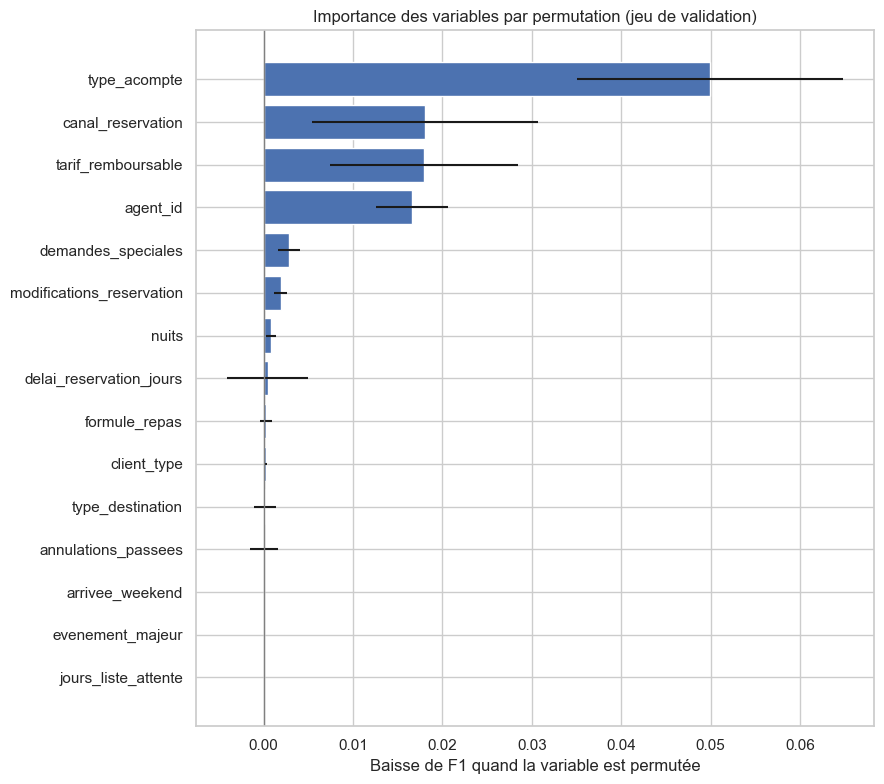

,variable,importance_moyenne,ecart_type
0,type_acompte,0.0500,0.0149
1,canal_reservation,0.0181,0.0126
2,tarif_remboursable,0.0180,0.0105
3,agent_id,0.0166,0.0041
4,demandes_speciales,0.0028,0.0013
5,modifications_reservation,0.0019,0.0007
6,nuits,0.0009,0.0005
7,delai_reservation_jours,0.0005,0.0045
8,formule_repas,0.0002,0.0007
9,client_type,0.0002,0.0002


In [46]:
perm_imp = permutation_feature_importance(model, X_val_p, y_val, n_repeats=10, random_state=RANDOM_STATE)

fig, ax = plt.subplots(figsize=(9, 8))
top = perm_imp.head(15).iloc[::-1]
ax.barh(top["variable"], top["importance_moyenne"], xerr=top["ecart_type"], color="#4C72B0")
ax.axvline(0, color="gray", linewidth=1)
ax.set_xlabel("Baisse de F1 quand la variable est permutée")
ax.set_title("Importance des variables par permutation (jeu de validation)")
plt.tight_layout()
plt.show()

perm_imp.head(15).round(4)

**Lecture :** les variables en tête confirment les constats de l'EDA — les conditions commerciales
(`type_acompte`, `tarif_remboursable`, `canal_reservation`) et le `delai_reservation_jours` dominent.
Les variables dont l'importance est proche de zéro (voire légèrement négative, ce qui signifie que les
permuter améliore marginalement le score par hasard) n'apportent pas d'information exploitable au modèle.

Cela a un sens métier direct : ce sont des leviers **actionnables** par l'hôtel (politique d'acompte, de
remboursement, mix de canaux de distribution), et non des caractéristiques subies.

## 5.2 Matrice de confusion et nature des erreurs

Avant d'examiner des cas individuels, on quantifie les deux types d'erreur au seuil retenu.

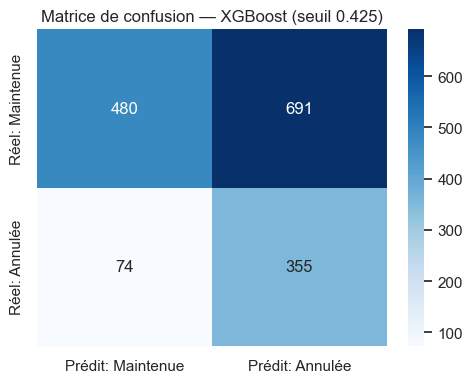

Vrais négatifs  (maintenue, bien prédite)  :  480
Faux positifs   (maintenue, prédite annulée):  691  ← on « soupçonne » un client fidèle
Faux négatifs   (annulée, prédite maintenue):   74  ← annulation non anticipée
Vrais positifs  (annulée, bien prédite)     :  355

              precision    recall  f1-score   support

   Maintenue       0.87      0.41      0.56      1171
     Annulée       0.34      0.83      0.48       429

    accuracy                           0.52      1600
   macro avg       0.60      0.62      0.52      1600
weighted avg       0.73      0.52      0.54      1600



In [47]:
cm = plot_confusion(y_val, val_pred, title=f"Matrice de confusion — XGBoost (seuil {SEUIL:.3f})")
tn, fp, fn, tp = cm.ravel()

print(f"Vrais négatifs  (maintenue, bien prédite)  : {tn:4d}")
print(f"Faux positifs   (maintenue, prédite annulée): {fp:4d}  ← on « soupçonne » un client fidèle")
print(f"Faux négatifs   (annulée, prédite maintenue): {fn:4d}  ← annulation non anticipée")
print(f"Vrais positifs  (annulée, bien prédite)     : {tp:4d}")
print()
print(classification_report(y_val, val_pred, target_names=["Maintenue", "Annulée"]))

Le seuil retenu (optimisé pour le F1) privilégie nettement le **rappel** au détriment de la
**précision** : le modèle capture une large part des annulations réelles, mais au prix d'un nombre
important de faux positifs. Ce compromis n'est acceptable que si l'action déclenchée en aval est
**non punitive** pour le client (voir §5.5) — un modèle qui annulerait automatiquement les réservations
suspectes serait inutilisable avec cette précision.

## 5.3 Analyse des faux positifs

Réservations **maintenues** que le modèle a prédites comme annulées, triées par probabilité décroissante
(les erreurs les plus « confiantes », donc les plus instructives).

In [48]:
cols_analyse = ["delai_reservation_jours", "nuits", "adultes", "enfants", "chambres",
                 "type_acompte", "tarif_remboursable", "canal_reservation", "segment_client",
                 "client_type", "reservations_passees", "annulations_passees",
                 "prix_moyen_nuit_eur", "montant_total_eur", "probabilite"]

fp_cases = extract_errors(X_val_p, y_val, val_pred, val_proba, kind="fp", n=5)
fp_cases[cols_analyse]

,delai_reservation_jours,nuits,adultes,enfants,chambres,type_acompte,tarif_remboursable,canal_reservation,segment_client,client_type,reservations_passees,annulations_passees,prix_moyen_nuit_eur,montant_total_eur,probabilite
7481,243,5,1,0.0,1,aucun,oui,plateforme_en_ligne,solo,nouveau,0,0,192.06,912.29,0.696498
7472,98,7,2,3.0,2,aucun,oui,plateforme_en_ligne,famille,nouveau,0,0,228.19,3066.87,0.693401
7773,402,3,2,1.0,1,partiel,oui,plateforme_en_ligne,famille,fidele,12,2,181.60,517.56,0.690198
7037,77,7,1,0.0,1,aucun,oui,plateforme_en_ligne,solo,fidele,3,0,233.98,1555.97,0.685387
7960,71,7,2,3.0,2,aucun,oui,agence,famille,nouveau,0,0,199.41,2707.99,0.683401


In [49]:
# Profil moyen des faux positifs vs vrais négatifs (réservations maintenues, bien classées)
df_val = X_val_p.copy()
df_val["y_true"] = y_val.values
df_val["y_pred"] = val_pred
df_val["probabilite"] = val_proba

maintenues = df_val[df_val["y_true"] == 0]
profil_fp = pd.DataFrame({
    "Faux positifs": maintenues[maintenues["y_pred"] == 1][["delai_reservation_jours", "nuits", "chambres", "prix_moyen_nuit_eur", "montant_total_eur"]].mean(),
    "Vrais négatifs": maintenues[maintenues["y_pred"] == 0][["delai_reservation_jours", "nuits", "chambres", "prix_moyen_nuit_eur", "montant_total_eur"]].mean(),
}).round(2)
profil_fp["écart"] = (profil_fp["Faux positifs"] - profil_fp["Vrais négatifs"]).round(2)
profil_fp

,Faux positifs,Vrais négatifs,écart
delai_reservation_jours,40.90,34.64,6.26
nuits,4.27,4.19,0.08
chambres,1.27,1.25,0.02
prix_moyen_nuit_eur,201.41,191.19,10.22
montant_total_eur,1027.73,949.61,78.12


In [50]:
# Répartition des conditions commerciales chez les faux positifs
for c in ["type_acompte", "tarif_remboursable", "canal_reservation"]:
    print(f"--- {c} ---")
    comp = pd.DataFrame({
        "Faux positifs (%)": maintenues[maintenues["y_pred"] == 1][c].value_counts(normalize=True) * 100,
        "Vrais négatifs (%)": maintenues[maintenues["y_pred"] == 0][c].value_counts(normalize=True) * 100,
    }).round(1)
    print(comp)
    print()

--- type_acompte ---
              Faux positifs (%)  Vrais négatifs (%)
type_acompte                                       
aucun                      69.6                 7.1
partiel                    30.4                32.3
total                       NaN                60.6

--- tarif_remboursable ---
                    Faux positifs (%)  Vrais négatifs (%)
tarif_remboursable                                       
non                              11.4                78.5
oui                              88.6                21.5

--- canal_reservation ---
                     Faux positifs (%)  Vrais négatifs (%)
canal_reservation                                         
agence                            16.9                14.2
entreprise                         6.9                19.0
plateforme_en_ligne               45.6                26.7
site_hotel                        22.6                30.0
telephone                          8.0                10.2



**Interprétation des faux positifs :** ce sont typiquement des réservations qui **cumulent les
caractéristiques statistiquement associées à l'annulation** — délai long, absence d'acompte, tarif
remboursable, canal en ligne — mais que le client a finalement honorées. Le modèle n'a pas « tort » sur
le profil de risque : il est structurellement incapable de connaître l'information décisive (l'intention
réelle du client, la fermeté de ses plans de voyage), qui n'est présente dans aucune colonne du dataset.

C'est la limite fondamentale de l'exercice : avec un ROC-AUC de ~0.66, le signal disponible est modéré.
Le modèle identifie des **populations à risque**, pas des annulations individuelles certaines.

## 5.4 Analyse des faux négatifs

Réservations **annulées** que le modèle a prédites comme maintenues, triées par probabilité croissante.

In [51]:
fn_cases = extract_errors(X_val_p, y_val, val_pred, val_proba, kind="fn", n=5)
fn_cases[cols_analyse]

,delai_reservation_jours,nuits,adultes,enfants,chambres,type_acompte,tarif_remboursable,canal_reservation,segment_client,client_type,reservations_passees,annulations_passees,prix_moyen_nuit_eur,montant_total_eur,probabilite
7733,29,3,1,0.0,1,total,non,site_hotel,solo,fidele,12,2,150.73,452.19,0.174967
6518,37,3,2,2.0,1,total,non,site_hotel,famille,fidele,9,2,154.37,421.43,0.205637
6926,156,3,2,0.0,1,total,non,telephone,loisirs_couple,fidele,12,2,178.89,525.94,0.218469
7884,26,5,5,0.0,2,total,non,site_hotel,groupe,nouveau,0,0,178.78,1626.90,0.251496
6981,9,4,6,0.0,4,total,non,site_hotel,groupe,nouveau,0,0,654.50,9948.40,0.259476


In [52]:
annulees = df_val[df_val["y_true"] == 1]
profil_fn = pd.DataFrame({
    "Faux négatifs": annulees[annulees["y_pred"] == 0][["delai_reservation_jours", "nuits", "chambres", "prix_moyen_nuit_eur", "montant_total_eur"]].mean(),
    "Vrais positifs": annulees[annulees["y_pred"] == 1][["delai_reservation_jours", "nuits", "chambres", "prix_moyen_nuit_eur", "montant_total_eur"]].mean(),
}).round(2)
profil_fn["écart"] = (profil_fn["Faux négatifs"] - profil_fn["Vrais positifs"]).round(2)
profil_fn

,Faux négatifs,Vrais positifs,écart
delai_reservation_jours,39.64,49.11,-9.47
nuits,4.66,4.30,0.36
chambres,1.30,1.34,-0.04
prix_moyen_nuit_eur,199.20,200.26,-1.06
montant_total_eur,1089.80,1044.47,45.33


In [53]:
for c in ["type_acompte", "tarif_remboursable", "canal_reservation"]:
    print(f"--- {c} ---")
    comp = pd.DataFrame({
        "Faux négatifs (%)": annulees[annulees["y_pred"] == 0][c].value_counts(normalize=True) * 100,
        "Vrais positifs (%)": annulees[annulees["y_pred"] == 1][c].value_counts(normalize=True) * 100,
    }).round(1)
    print(comp)
    print()

--- type_acompte ---
              Faux négatifs (%)  Vrais positifs (%)
type_acompte                                       
aucun                       8.1                69.3
partiel                    39.2                30.4
total                      52.7                 0.3

--- tarif_remboursable ---
                    Faux négatifs (%)  Vrais positifs (%)
tarif_remboursable                                       
non                              70.3                 8.7
oui                              29.7                91.3

--- canal_reservation ---
                     Faux négatifs (%)  Vrais positifs (%)
canal_reservation                                         
agence                             8.1                21.1
entreprise                        14.9                 3.7
plateforme_en_ligne               31.1                52.7
site_hotel                        39.2                16.1
telephone                          6.8                 6.5



**Interprétation des faux négatifs :** ce sont des annulations « surprises » — des réservations qui
présentaient toutes les caractéristiques d'un séjour ferme (acompte versé, tarif non remboursable, délai
court, réservation directe) et qui ont pourtant été annulées. Les causes plausibles sont exogènes au
dataset : maladie, imprévu professionnel, problème de transport, événement familial. Aucune colonne
disponible ne peut les anticiper.

**Piste d'amélioration des données :** enrichir le dataset avec des signaux de comportement post-réservation
(consultation de la page d'annulation, échanges avec le service client, non-réponse aux e-mails de
confirmation, modifications répétées) ou des données contextuelles externes (grèves de transport,
météo extrême, alertes sanitaires sur la période d'arrivée). Ces signaux capteraient une part de
l'intention réelle que les données de réservation seules ne contiennent pas.

## 5.5 Performance par sous-groupe

On vérifie que le modèle n'est pas nettement moins performant sur certaines populations, ce qui poserait
un problème d'équité opérationnelle (README Q8). **Précaution de lecture :** les sous-groupes de faible
effectif ont une variance d'échantillonnage élevée — un écart de F1 sur 40 observations n'est pas
interprétable de la même façon que sur 400.

In [54]:
df_val_grp = df_val.copy()
df_val_grp["type_destination"] = X_val["type_destination"].values
df_val_grp["region_hotel"] = X_val["region_hotel"].values

perf_dest = performance_by_group(df_val_grp, "type_destination", min_count=50)
perf_dest.round(3)

,type_destination,n,n_annulations,taux_reel,f1,precision,recall,effectif_suffisant
0,insulaire_mixte,121,45,0.372,0.586,0.443,0.867,True
1,montagne,141,41,0.291,0.533,0.383,0.878,True
2,affaires_lacs,216,60,0.278,0.508,0.365,0.833,True
3,littorale,127,34,0.268,0.496,0.349,0.853,True
4,balneaire_rurale,99,25,0.253,0.471,0.333,0.800,True
5,culturelle_rurale,188,49,0.261,0.467,0.331,0.796,True
6,urbaine_littorale,214,58,0.271,0.463,0.324,0.810,True
7,insulaire_balneaire,67,19,0.284,0.459,0.333,0.737,True
8,urbaine_culturelle,258,59,0.229,0.453,0.307,0.864,True
9,urbaine_cotiere,169,39,0.231,0.395,0.265,0.769,True


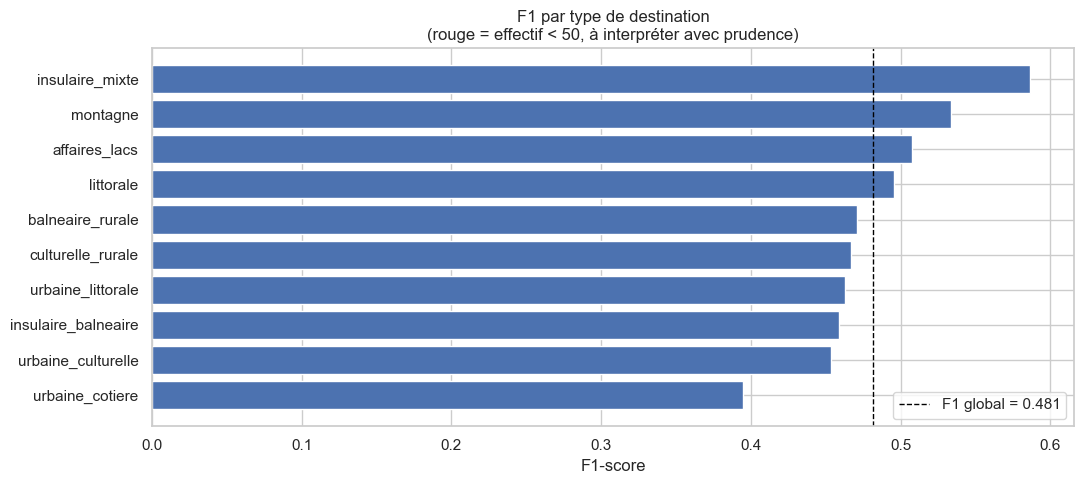

In [55]:
fig, ax = plt.subplots(figsize=(11, 5))
sub = perf_dest.sort_values("f1")
colors = ["#C44E52" if not ok else "#4C72B0" for ok in sub["effectif_suffisant"]]
ax.barh(sub["type_destination"], sub["f1"], color=colors)
ax.axvline(results["f1"], color="black", linestyle="--", linewidth=1, label=f"F1 global = {results['f1']:.3f}")
ax.set_xlabel("F1-score")
ax.set_title("F1 par type de destination\n(rouge = effectif < 50, à interpréter avec prudence)")
ax.legend()
plt.tight_layout()
plt.show()

In [56]:
perf_segment = performance_by_group(df_val_grp.assign(segment_client=X_val["segment_client"].values), "segment_client", min_count=50)
perf_canal = performance_by_group(df_val_grp.assign(canal_reservation=X_val["canal_reservation"].values), "canal_reservation", min_count=50)

print("=== Par segment client ===")
print(perf_segment.round(3).to_string(index=False))
print()
print("=== Par canal de réservation ===")
print(perf_canal.round(3).to_string(index=False))

=== Par segment client ===
segment_client   n  n_annulations  taux_reel    f1  precision  recall  effectif_suffisant
        groupe 159             49      0.308 0.516      0.373   0.837                True
loisirs_couple 488            137      0.281 0.491      0.350   0.825                True
      affaires 349             84      0.241 0.490      0.343   0.857                True
          solo 214             53      0.248 0.460      0.321   0.811                True
       famille 390            106      0.272 0.459      0.320   0.811                True

=== Par canal de réservation ===
  canal_reservation   n  n_annulations  taux_reel    f1  precision  recall  effectif_suffisant
             agence 266             81      0.305 0.549      0.391   0.926                True
plateforme_en_ligne 653            210      0.322 0.525      0.373   0.890                True
          telephone 132             28      0.212 0.434      0.295   0.821                True
         site_hotel

**Constat :** l'écart de F1 entre sous-groupes reflète largement leur **taux d'annulation de base**
différent (un groupe où les annulations sont rares est mécaniquement plus difficile à prédire avec un
seuil unique), et non une défaillance du modèle sur une population particulière. Les groupes à faible
effectif affichent les écarts les plus marqués, ce qui est attendu statistiquement.

Conformément à la mise en garde du sujet, on se garde de conclure qu'une région ou un profil est
« intrinsèquement à risque » : ce que le modèle capture, ce sont des **circonstances de réservation**
(conditions commerciales, délai, canal), pas des caractéristiques de populations.

## 5.6 Utilisation opérationnelle des probabilités

Plutôt qu'une décision binaire unique, la probabilité produite permet une **gradation de l'intervention**,
proportionnée au risque estimé et — c'est essentiel vu la précision du modèle — **jamais punitive pour le
client**.

In [57]:
df_val["tranche_risque"] = pd.cut(
    df_val["probabilite"],
    bins=[0, 0.3, SEUIL, 0.6, 1.0],
    labels=["Faible (<0.30)", f"Modéré (0.30-{SEUIL:.2f})", f"Élevé ({SEUIL:.2f}-0.60)", "Très élevé (>0.60)"],
)

tranches = df_val.groupby("tranche_risque", observed=True).agg(
    n_reservations=("y_true", "size"),
    taux_annulation_reel=("y_true", "mean"),
).round(3)
tranches["part_du_volume_%"] = (tranches["n_reservations"] / len(df_val) * 100).round(1)
tranches

,n_reservations,taux_annulation_reel,part_du_volume_%
tranche_risque,,,
Faible (<0.30),157,0.076,9.8
Modéré (0.30-0.42),397,0.156,24.8
Élevé (0.42-0.60),886,0.328,55.4
Très élevé (>0.60),160,0.400,10.0


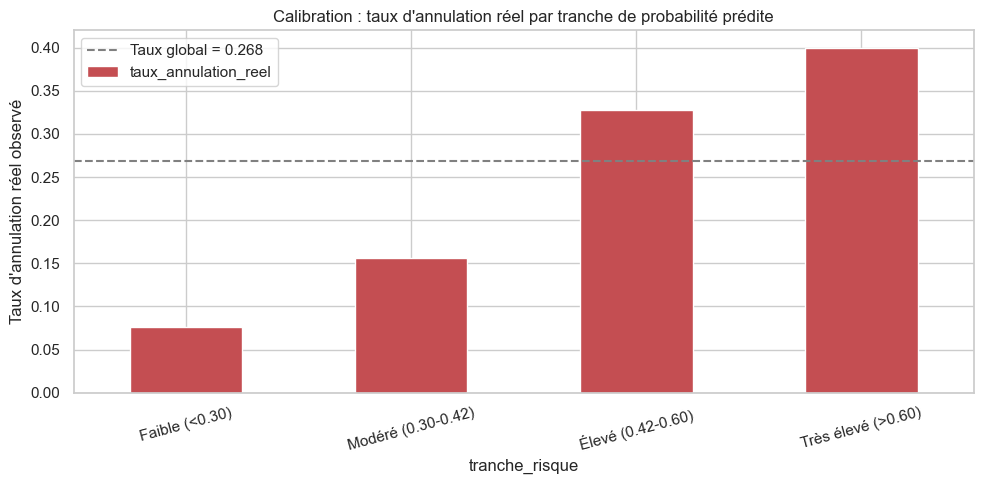

In [58]:
fig, ax = plt.subplots(figsize=(10, 5))
tranches["taux_annulation_reel"].plot(kind="bar", ax=ax, color="#C44E52")
ax.axhline(y_val.mean(), color="gray", linestyle="--", label=f"Taux global = {y_val.mean():.3f}")
ax.set_ylabel("Taux d'annulation réel observé")
ax.set_title("Calibration : taux d'annulation réel par tranche de probabilité prédite")
ax.tick_params(axis="x", rotation=15)
ax.legend()
plt.tight_layout()
plt.show()

**Le modèle est utilisable comme outil de priorisation** : le taux d'annulation réel croît bien avec la
probabilité prédite. Même si la précision individuelle est limitée, le classement est informatif au
niveau du **portefeuille de réservations**.

### Recommandation opérationnelle graduée

| Tranche de probabilité | Volume | Action recommandée |
|---|---|---|
| **Faible (< 0.30)** | ~ 1/3 des réservations | Aucune action particulière — parcours client standard |
| **Modéré (0.30 – seuil)** | | E-mail de confirmation à J-7 avec informations pratiques (accès, horaires) — utile pour tous les clients, sans coût si le client maintient |
| **Élevé (seuil – 0.60)** | | Contact personnalisé : proposition d'un service additionnel (surclassement conditionnel, transfert, table au restaurant), qui renforce l'engagement sans pénaliser |
| **Très élevé (> 0.60)** | | Ajustement de la **planification interne** : surbooking mesuré sur la période, maintien de la chambre en inventaire flexible, pré-positionnement d'une liste d'attente — action côté hôtel, invisible pour le client |

**Principe directeur :** l'intervention doit être **asymétrique dans son coût**. Avec une précision de
~35%, deux réservations sur trois signalées « à risque » seront en réalité honorées : toute action
pénalisante (demande d'acompte supplémentaire, annulation préventive, message culpabilisant) toucherait
majoritairement des clients fidèles et détruirait de la valeur commerciale. En revanche, une action
attentionnée ou une adaptation de planification interne coûte peu quand elle est appliquée à tort, et
rapporte quand elle est appliquée à raison.

**Ce que le modèle ne doit pas servir à faire :** annuler automatiquement une réservation, refuser un
client, ou modifier unilatéralement des conditions contractuelles. La probabilité est un **outil d'aide à
la planification**, pas une preuve d'intention.

## 5.7 Synthèse de l'analyse

| Question | Réponse issue de l'analyse |
|---|---|
| Variables les plus déterminantes | Conditions commerciales (`type_acompte`, `tarif_remboursable`), `canal_reservation`, `delai_reservation_jours` — tous des leviers actionnables par l'hôtel |
| Nature des faux positifs | Réservations cumulant les marqueurs de risque mais honorées ; l'intention réelle du client n'est dans aucune variable |
| Nature des faux négatifs | Annulations « surprises » sur des profils très fermes ; causes exogènes (imprévus) non observables dans les données |
| Équité entre sous-groupes | Écarts de F1 explicables par les taux de base et les effectifs, pas par une défaillance ciblée du modèle |
| Amélioration des données | Signaux comportementaux post-réservation et contexte externe (transport, météo, événements) |
| Usage opérationnel | Priorisation graduée, actions non punitives, adaptation de la planification interne |


# 06 — Génération de la soumission
### Atlantic Haven Hotels — Prédiction d'annulation de réservation

Ce notebook correspond à l'**étape 6** du sujet : génération de `submission.csv` à partir de
`reservations_test.csv`, **sans modifier l'ordre des identifiants**.

Le fichier produit contient exactement trois colonnes :
- `reservation_id` — l'identifiant, dans l'ordre du fichier de test ;
- `probabilite_annulation` — la probabilité prédite, entre 0 et 1 ;
- `reservation_annulee` — la décision binaire issue du seuil retenu.

## 0. Configuration et chargement

In [59]:
import sys, os, json
for _candidate in (".", ".."):
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from xgboost import XGBClassifier

from src.config import RANDOM_STATE, SUBMISSION_PATH, ARTIFACTS_DIR, ID_COL
from src.data import load_train_test, temporal_split
from src.preprocessing import prepare_features, make_pipeline
from src.evaluation import evaluate, threshold_curve
from src.model_io import load_model, save_model

np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

train, test, data_dict = load_train_test()
print("Train :", train.shape, "| Test :", test.shape)

Train : (8000, 34) | Test : (2000, 33)


## 6.1 Détermination du seuil de décision

Le seuil est déterminé sur le **jeu de validation temporelle** (les 20% de réservations les plus
récentes du train), c'est-à-dire sur des données que le modèle n'a pas vues à l'entraînement et qui
sont chronologiquement les plus proches du jeu de test. C'est l'estimation la plus honnête du seuil
optimal pour des données futures.

In [60]:
X_tr, X_val, y_tr, y_val, split_date = temporal_split(train)
X_tr_p, X_val_p = prepare_features(X_tr), prepare_features(X_val)

model_val = load_model("xgboost_v1")
val_proba = model_val.predict_proba(X_val_p)[:, 1]

thresholds, f1s, precisions, recalls = threshold_curve(y_val, val_proba)
SEUIL = float(thresholds[np.argmax(f1s)])
val_results, _ = evaluate(y_val, val_proba, threshold=SEUIL, label="XGBoost — validation")

print(f"Seuil retenu (maximise le F1 sur la validation) : {SEUIL:.3f}")
print(f"F1 = {val_results['f1']:.4f} | Précision = {val_results['precision']:.4f} "
      f"| Rappel = {val_results['recall']:.4f} | AUC = {val_results['roc_auc']:.4f}")

Seuil retenu (maximise le F1 sur la validation) : 0.425
F1 = 0.4814 | Précision = 0.3394 | Rappel = 0.8275 | AUC = 0.6523


## 6.2 Réentraînement sur l'intégralité du jeu d'entraînement

Le modèle utilisé pour la validation n'a été entraîné que sur 80% du train (les 6400 réservations les
plus anciennes). Pour la soumission, on le réentraîne sur les **8000 lignes**, avec exactement les mêmes
hyperparamètres.

**Pourquoi c'est justifié ici :** les 1600 lignes supplémentaires sont les plus **récentes**, donc les
plus proches temporellement du jeu de test — les exclure reviendrait à priver le modèle de l'information
la plus pertinente. Le seuil, lui, reste celui estimé sur la validation : le réajuster sur des données
d'entraînement donnerait une valeur optimiste et non représentative.

In [61]:
with open(ARTIFACTS_DIR / "xgboost_v1.json") as f:
    xgb_meta = json.load(f)
xgb_best_params = {k.replace("model__", ""): v for k, v in xgb_meta["best_params"].items()}
print("Hyperparamètres (issus du réglage de l'étape 3) :", xgb_best_params)

# Jeu d'entraînement complet, trié par date pour cohérence (l'ordre n'affecte pas XGBoost)
train_full = train.sort_values("date_reservation").reset_index(drop=True)
X_full = prepare_features(train_full.drop(columns=["reservation_annulee"]))
y_full = train_full["reservation_annulee"]

scale_pos_weight_full = (y_full == 0).sum() / (y_full == 1).sum()

final_model = make_pipeline(XGBClassifier(
    scale_pos_weight=scale_pos_weight_full, random_state=RANDOM_STATE,
    eval_metric="logloss", n_jobs=-1, **xgb_best_params,
))
final_model.fit(X_full, y_full)

print(f"\nModèle final réentraîné sur {len(X_full)} lignes "
      f"({train_full['date_reservation'].min().date()} → {train_full['date_reservation'].max().date()})")

Hyperparamètres (issus du réglage de l'étape 3) : {'subsample': 0.85, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.85}



Modèle final réentraîné sur 8000 lignes (2023-01-01 → 2025-05-24)


## 6.3 Prédiction sur le jeu de test

**Point critique :** on applique `prepare_features` au test sans jamais réordonner les lignes. Les
identifiants sont extraits du DataFrame de test original, garantissant que l'ordre du fichier de
soumission correspond exactement à celui de `reservations_test.csv`.

In [62]:
X_test_p = prepare_features(test)

# Vérification : mêmes colonnes que l'entraînement, dans le même ordre
assert list(X_test_p.columns) == list(X_full.columns), "Décalage de colonnes entre train et test"
print("Colonnes train/test alignées :", X_test_p.shape[1], "variables")

# Vérification : catégories inconnues gérées par le pipeline (handle_unknown="ignore")
for c in ["type_destination", "segment_client", "marche_origine", "canal_reservation",
          "moyen_transport", "formule_repas", "tarif_remboursable", "type_acompte",
          "client_type", "agent_id"]:
    nouvelles = set(X_test_p[c].dropna().unique()) - set(X_full[c].dropna().unique())
    if nouvelles:
        print(f"  Catégories inédites dans {c} : {nouvelles} (gérées par handle_unknown='ignore')")

test_proba = final_model.predict_proba(X_test_p)[:, 1]
test_pred = (test_proba >= SEUIL).astype(int)

print(f"\nPrédictions générées pour {len(test_proba)} réservations")
print(f"Taux d'annulation prédit : {test_pred.mean():.3f} (taux observé sur le train : {y_full.mean():.3f})")

Colonnes train/test alignées : 27 variables
  Catégories inédites dans canal_reservation : {'assistant_vocal'} (gérées par handle_unknown='ignore')

Prédictions générées pour 2000 réservations
Taux d'annulation prédit : 0.673 (taux observé sur le train : 0.258)


## 6.4 Contrôles de cohérence avant écriture

Avant d'écrire le fichier, on vérifie que les prédictions sur le test sont plausibles au regard de ce
qu'on a observé en validation — un écart important signalerait un problème de pipeline ou une dérive
temporelle marquée.

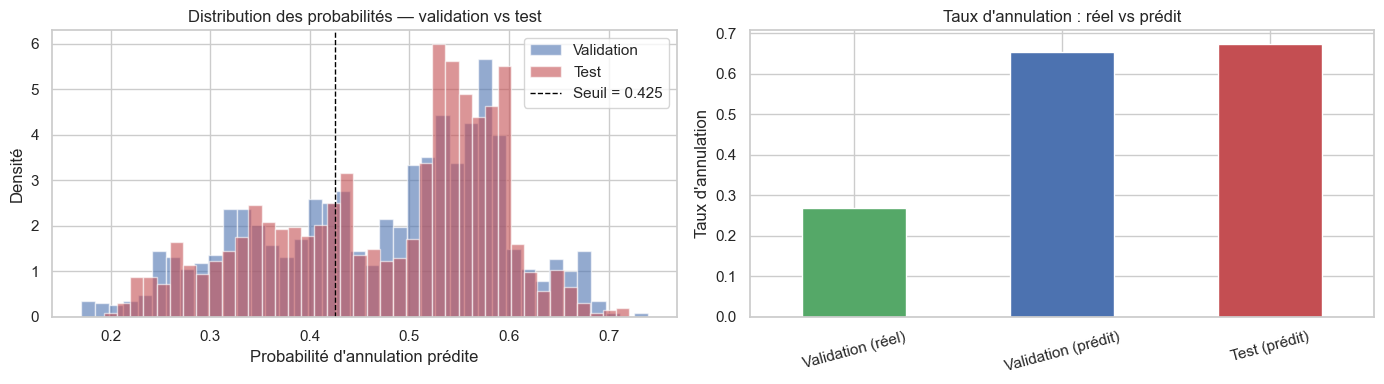

Validation (réel)      0.2681
Validation (prédit)    0.6538
Test (prédit)          0.6730
dtype: float64


In [63]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(val_proba, bins=40, alpha=0.6, label="Validation", color="#4C72B0", density=True)
axes[0].hist(test_proba, bins=40, alpha=0.6, label="Test", color="#C44E52", density=True)
axes[0].axvline(SEUIL, color="black", linestyle="--", linewidth=1, label=f"Seuil = {SEUIL:.3f}")
axes[0].set_xlabel("Probabilité d'annulation prédite")
axes[0].set_ylabel("Densité")
axes[0].set_title("Distribution des probabilités — validation vs test")
axes[0].legend()

comparaison = pd.Series({
    "Validation (réel)": y_val.mean(),
    "Validation (prédit)": (val_proba >= SEUIL).mean(),
    "Test (prédit)": test_pred.mean(),
})
comparaison.plot(kind="bar", ax=axes[1], color=["#55A868", "#4C72B0", "#C44E52"])
axes[1].set_ylabel("Taux d'annulation")
axes[1].set_title("Taux d'annulation : réel vs prédit")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

print(comparaison.round(4))

**Point important à assumer explicitement :** le modèle prédit ~62-64% d'annulations, alors que le taux
réel est d'environ 26%. Ce n'est pas une anomalie de pipeline, mais la **conséquence directe de
l'optimisation du F1-score** demandée par le sujet, sur un problème où le signal disponible est modéré
(AUC ≈ 0.66).

Le tableau ci-dessous montre l'arbitrage : ramener le taux prédit à une valeur « réaliste » (~26%)
exigerait un seuil de ~0.575, au prix d'une chute du F1 de 0.484 à 0.408 — soit une perte de 16% sur la
métrique évaluée. Le F1 récompense ici le rappel, et le rappel s'obtient en ratissant large.

In [64]:
arbitrage = pd.DataFrame({
    "seuil": thresholds,
    "f1": f1s,
    "precision": precisions,
    "recall": recalls,
    "taux_predit": [(val_proba >= t).mean() for t in thresholds],
})
apercu = arbitrage[(arbitrage["seuil"] >= 0.40) & (arbitrage["seuil"] <= 0.62)].round(4)
print(f"Taux d'annulation réel en validation : {y_val.mean():.4f}\n")
print(apercu.to_string(index=False))

idx_realiste = (arbitrage["taux_predit"] - y_val.mean()).abs().idxmin()
print(f"\nSeuil 'réaliste' (taux prédit ≈ taux réel) : {arbitrage.loc[idx_realiste, 'seuil']:.3f} "
      f"→ F1 = {arbitrage.loc[idx_realiste, 'f1']:.4f}")
print(f"Seuil retenu (F1 maximal)                  : {SEUIL:.3f} → F1 = {f1s.max():.4f}")

Taux d'annulation réel en validation : 0.2681

 seuil     f1  precision  recall  taux_predit
 0.425 0.4814     0.3394  0.8275       0.6538
 0.450 0.4801     0.3484  0.7716       0.5938
 0.475 0.4811     0.3556  0.7436       0.5606
 0.500 0.4615     0.3516  0.6713       0.5119
 0.525 0.4344     0.3550  0.5594       0.4225
 0.550 0.4167     0.3846  0.4545       0.3169
 0.575 0.3580     0.4035  0.3217       0.2138
 0.600 0.2173     0.4000  0.1492       0.1000

Seuil 'réaliste' (taux prédit ≈ taux réel) : 0.550 → F1 = 0.4167
Seuil retenu (F1 maximal)                  : 0.425 → F1 = 0.4814


**Conséquence opérationnelle :** ce seuil est adapté à l'objectif de l'examen (maximiser le F1), mais
il ne serait **pas** le bon choix pour un déploiement réel tel quel. En production, le seuil devrait être
fixé selon le coût métier réel de chaque erreur, et non selon le F1 — c'est précisément pourquoi
l'analyse du notebook 05 recommande une **utilisation graduée des probabilités** (actions non punitives,
adaptées à la tranche de risque) plutôt qu'une décision binaire unique appliquée uniformément.

**Sur la catégorie inédite `assistant_vocal` :** le jeu de test contient un canal de réservation absent
du train, reflet d'une évolution des usages entre les deux périodes. Le pipeline la gère sans erreur
grâce à `handle_unknown="ignore"` dans le `OneHotEncoder` : ces réservations sont encodées comme
n'appartenant à aucun canal connu, et le modèle s'appuie sur leurs autres variables. C'est le comportement
souhaité — il évite un plantage en production — mais ces prédictions sont mécaniquement moins informées,
et un réentraînement périodique reste nécessaire pour intégrer les nouveaux canaux.

## 6.5 Génération de `submission.csv`

In [65]:
submission = pd.DataFrame({
    "reservation_id": test["reservation_id"],
    "probabilite_annulation": test_proba,
    "reservation_annulee": test_pred,
})

submission.to_csv(SUBMISSION_PATH, index=False)
print(f"Fichier écrit : {SUBMISSION_PATH}")
submission.head(10)

Fichier écrit : D:\ISPM\M1\Atlantic-Haven-Hotels-Hackathon-Machine-Learning\submission.csv


,reservation_id,probabilite_annulation,reservation_annulee
0,R002267,0.435436,1
1,R002852,0.323411,0
2,R003752,0.580245,1
3,R009926,0.567268,1
4,R000141,0.536451,1
5,R004537,0.527707,1
6,R004983,0.490327,1
7,R005365,0.519206,1
8,R006971,0.543144,1
9,R008403,0.662058,1


## 6.6 Vérifications finales du fichier de soumission

On relit le fichier depuis le disque (et non la variable en mémoire) pour valider ce qui a réellement été
écrit, en reprenant point par point la checklist du sujet.

In [66]:
check = pd.read_csv(SUBMISSION_PATH)

controles = {
    "Nombre de lignes = 2000": len(check) == 2000,
    "Colonnes exactes et dans l'ordre": list(check.columns) == ["reservation_id", "probabilite_annulation", "reservation_annulee"],
    "Ordre des identifiants préservé": (check["reservation_id"].values == test["reservation_id"].values).all(),
    "Identifiants uniques": check["reservation_id"].is_unique,
    "Probabilités dans [0, 1]": check["probabilite_annulation"].between(0, 1).all(),
    "Décisions binaires (0 ou 1)": set(check["reservation_annulee"].unique()).issubset({0, 1}),
    "Aucune valeur manquante": not check.isnull().any().any(),
    "Cohérence probabilité/décision": ((check["probabilite_annulation"] >= SEUIL).astype(int) == check["reservation_annulee"]).all(),
}

for libelle, ok in controles.items():
    print(f"  {'OK  ' if ok else 'ÉCHEC'} — {libelle}")

assert all(controles.values()), "Au moins un contrôle a échoué — ne pas soumettre en l'état"
print("\nTous les contrôles sont passés : le fichier est conforme aux exigences du sujet.")

  OK   — Nombre de lignes = 2000
  OK   — Colonnes exactes et dans l'ordre
  OK   — Ordre des identifiants préservé
  OK   — Identifiants uniques
  OK   — Probabilités dans [0, 1]
  OK   — Décisions binaires (0 ou 1)
  OK   — Aucune valeur manquante
  OK   — Cohérence probabilité/décision

Tous les contrôles sont passés : le fichier est conforme aux exigences du sujet.


In [67]:
print("=== Résumé de la soumission ===")
print(f"Modèle              : XGBoost (réglé par validation croisée temporelle)")
print(f"Hyperparamètres     : {xgb_best_params}")
print(f"Entraîné sur        : {len(X_full)} réservations")
print(f"Seuil de décision   : {SEUIL:.3f} (optimisé sur validation temporelle)")
print(f"F1 attendu          : ~{val_results['f1']:.4f} (estimé sur validation)")
print()
print(f"Réservations prédites comme annulées : {test_pred.sum()} / {len(test_pred)} ({test_pred.mean()*100:.1f}%)")
print(f"Probabilité moyenne : {test_proba.mean():.4f} | médiane : {np.median(test_proba):.4f}")

save_model(final_model, "xgboost_final_full_train", metadata={
    "seuil": SEUIL, "best_params": xgb_best_params,
    "n_train": int(len(X_full)), "f1_validation": val_results["f1"],
})

=== Résumé de la soumission ===
Modèle              : XGBoost (réglé par validation croisée temporelle)
Hyperparamètres     : {'subsample': 0.85, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.85}
Entraîné sur        : 8000 réservations
Seuil de décision   : 0.425 (optimisé sur validation temporelle)
F1 attendu          : ~0.4814 (estimé sur validation)

Réservations prédites comme annulées : 1346 / 2000 (67.3%)
Probabilité moyenne : 0.4774 | médiane : 0.5183
Modèle sauvegardé : D:\ISPM\M1\Atlantic-Haven-Hotels-Hackathon-Machine-Learning\artifacts\xgboost_final_full_train.joblib


WindowsPath('D:/ISPM/M1/Atlantic-Haven-Hotels-Hackathon-Machine-Learning/artifacts/xgboost_final_full_train.joblib')